# 🧬 MoleGuLAR: Molecule Generation using Reinforcement Learning and Alternating Rewards

This notebook implements the **full MoleGuLAR pipeline** for *de novo* drug-like molecule generation using:- A **Stack-Augmented RNN** generative model- **Reinforcement Learning** (REINFORCE / policy gradient) for property optimization- **Alternating reward** strategy for multi-objective optimization**Target proteins**: SARS-CoV-2 Mᵖʳᵒ (6LU7) and TTBK1 (4BTK)

**Reference**: [MoleGuLAR Paper](https://github.com/devalab/MoleGuLAR)

Furthermore, it tries to implement interpretability through an SSINet, ispired by the paper
> Self-Supervised Discovering of Interpretable
Features for Reinforcement Learning from Shi et al




## 📥 Setup & Installation
Install all required dependencies and clone the MoleGuLAR repo for data files.

In [1]:
!pip uninstall -y torch torchvision torchaudio dgl dgllife torchdata -q
!pip cache purge -q

### 🟢 Cuda

In [2]:
# Detect CUDA version from the system
import subprocess
cuda_raw = subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout
print(cuda_raw[:300])  # confirm GPU is visible

# Install torch FIRST, pinned to a real stable release
!pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 \
    --index-url https://download.pytorch.org/whl/cu121 -q

# Install DGL matched to torch 2.3 + cu121
!pip install dgl -f https://data.dgl.ai/wheels/torch-2.3/cu121/repo.html -q

# Rest of the stack, numpy unpinned
!pip install dgllife rdkit -q
!pip install scikit-learn pandas matplotlib seaborn tqdm joblib wandb -q

print("✓ All packages installed")

Thu Apr 16 14:42:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 20.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 92.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 77.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 42.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 97.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6

###  📥Imports

In [3]:
import torch, dgl, rdkit, sklearn, pandas, csv, time, warnings, os, sys, threading, random, shutil, joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import SVG, display
import seaborn as sns

from rdkit import Chem, RDLogger
from rdkit import DataStructs
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Crippen import MolLogP
from rdkit.Chem.QED import qed
from rdkit.Chem.rdMolDescriptors import CalcTPSA

from sklearn.model_selection import KFold

import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader

from dgl.nn.pytorch.glob import AvgPooling
from dgllife.utils import (
    mol_to_bigraph,
    PretrainAtomFeaturizer,
    PretrainBondFeaturizer,
    smiles_to_bigraph,
    CanonicalAtomFeaturizer,
    CanonicalBondFeaturizer
)
from dgllife.model import load_pretrained
from dgllife.model import MPNNPredictor

from tqdm import tqdm, trange


print(f"PyTorch  : {torch.__version__}")
print(f"CUDA ok  : {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"DGL      : {dgl.__version__}")
print(f"RDKit    : {rdkit.__version__}")
print(f"sklearn  : {sklearn.__version__}")
print(f"pandas   : {pandas.__version__}")
print(f"numpy    : {np.__version__}")

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
PyTorch  : 2.3.1+cu121
CUDA ok  : True — Tesla T4
DGL      : 2.5.0+cu121
RDKit    : 2026.03.1
sklearn  : 1.6.1
pandas   : 2.3.3
numpy    : 2.0.2


### 🗂️ Repo

In [4]:
# Clone the MoleGuLAR repo for data files (checkpoint, predictors, SMILES, PDBs)
# NOTE: platform detection (BASE_WORKING_DIR) is done below in Cell 10.
# We do a minimal inline detect here so the clone lands in the right place.

import os, subprocess, sys

_base = "/kaggle/working" if os.path.exists("/kaggle/working") else "/content"
REPO_URL  = "https://github.com/devalab/MoleGuLAR.git"
REPO_DIR  = os.path.join(_base, "MoleGuLAR")

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)

OPTIMIZER_DIR = os.path.join(REPO_DIR, "Optimizer")
os.environ['OPTIMIZER_DIR'] = OPTIMIZER_DIR
os.chdir(OPTIMIZER_DIR)
sys.path.insert(0, os.path.join(OPTIMIZER_DIR, 'release'))

print(f"Working directory : {os.getcwd()}")

required_files = [
    'random.smi',
    'checkpoints/generator/checkpoint_biggest_rnn',
    'Predictors/GINPredictor.tar',
    'Predictors/SolvationPredictor.tar',
]
for f in required_files:
    path = os.path.join(OPTIMIZER_DIR, f)
    ok   = os.path.exists(path)
    size = f" ({os.path.getsize(path)/1e6:.1f} MB)" if ok else ""
    print(f"  {'✅' if ok else '❌ MISSING'} {f}{size}")


Cloning into '/kaggle/working/MoleGuLAR'...


Working directory : /kaggle/working/MoleGuLAR/Optimizer
  ✅ random.smi (0.1 MB)
  ✅ checkpoints/generator/checkpoint_biggest_rnn (90.6 MB)
  ✅ Predictors/GINPredictor.tar (7.6 MB)
  ✅ Predictors/SolvationPredictor.tar (2.7 MB)


Updating files: 100% (49/49), done.


### 🌍 Environment Setup — Colab & Kaggle Compatibility

In [5]:
# ── Detect Platform & Set Base Path ──
import os

# Robust platform detection:
# - Kaggle kernels expose /kaggle/working and KAGGLE_* env vars
# - Real Colab runtimes expose /var/colab/hostname
is_kaggle = os.path.exists('/kaggle/working') or ('KAGGLE_KERNEL_RUN_TYPE' in os.environ)
is_colab_runtime = os.path.exists('/var/colab/hostname')

if is_kaggle:
    PLATFORM = "KAGGLE"
    BASE_WORKING_DIR = "/kaggle/working"
elif is_colab_runtime:
    PLATFORM = "COLAB"
    BASE_WORKING_DIR = "/content"
else:
    PLATFORM = "OTHER"
    BASE_WORKING_DIR = os.getcwd()

print(f"🖥️  Detected Platform: {PLATFORM}")
print(f"📁 Base Working Directory: {BASE_WORKING_DIR}")

# Update REPO_DIR based on platform
REPO_DIR = os.path.join(BASE_WORKING_DIR, "MoleGuLAR")

# On Colab, mount Google Drive for persistent storage (optional)
if PLATFORM == "COLAB":
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        print("✅ Google Drive mounted at /content/drive")
    except Exception as e:
        print(f"⚠️  Drive mount skipped: {e}")

# ── W&B API Key Setup ──
# Prefer secrets; avoid hardcoding keys in notebooks.
WANDB_API_KEY = os.getenv('WANDB_API_KEY', '')

if PLATFORM == "COLAB":
    try:
        from google.colab import userdata
        WANDB_API_KEY = userdata.get('WANDB_API_KEY') or WANDB_API_KEY
        if WANDB_API_KEY:
            print("✅ W&B API key loaded from Colab Secrets")
        else:
            print("⚠️  W&B API key not found in Colab Secrets. Set it in Tools -> Secrets.")
    except Exception:
        if WANDB_API_KEY:
            print("✅ W&B API key loaded from environment variable")
        else:
            print("⚠️  W&B API key not found. Set it in Tools -> Secrets or environment.")
elif PLATFORM == "KAGGLE":
    if WANDB_API_KEY:
        print("✅ W&B API key loaded from Kaggle Secrets")
    else:
        print("⚠️  W&B API key not found in Kaggle Secrets. Set it in Notebook Settings -> Secrets.")
else:
    if WANDB_API_KEY:
        print("✅ W&B API key loaded from environment variable")
    else:
        print("⚠️  W&B API key not found. Set WANDB_API_KEY in your environment.")

if WANDB_API_KEY:
    os.environ['WANDB_API_KEY'] = WANDB_API_KEY

print(f"📍 Repository will be cloned to: {REPO_DIR}")

🖥️  Detected Platform: KAGGLE
📁 Base Working Directory: /kaggle/working
⚠️  W&B API key not found in Kaggle Secrets. Set it in Notebook Settings -> Secrets.
📍 Repository will be cloned to: /kaggle/working/MoleGuLAR


## 🎛️ Configuration

Adjust experiment parameters below. This replaces the command-line `argparse` used in the original scripts.
| Parameter | Description |
|---|---|
| `PREDICTOR` | `"gin"` (recommended, no AutoDock needed) or `"dock"` (requires AutoDock-GPU) |
| `PROTEIN` | `"4BTK"` (TTBK1) or `"6LU7"` (SARS-CoV-2 Mᵖʳᵒ) — note: GIN only supports 4BTK |
| `REWARD_FUNCTION` | `"exponential"`, `"linear"`, `"logarithmic"`, or `"squared"` |
| `NUM_ITERATIONS` | Number of RL training iterations (default 175, use fewer for quick tests) |
| `USE_LOGP / USE_QED / ...` | Enable multi-objective optimization targets |
| `SWITCH_MODE` | `True` = alternating rewards, `False` = weighted sum |

In [6]:
# ── Predictor & Target ──
PREDICTOR = "gin"        # "gin" | "rfr" | "dock"
PROTEIN   = "4BTK"       # "4BTK" | "6LU7"

# ── Reward Function ──
REWARD_FUNCTION = "exponential"   # "exponential" | "linear" | "logarithmic" | "squared"

# ── Training ──
NUM_ITERATIONS = 175
N_POLICY       = 15
N_TO_GENERATE  = 100
SEED           = 0

# ── Multi-Objective Targets ──
USE_LOGP      = True
USE_QED       = True
USE_TPSA      = True
USE_SOLVATION = False

# ── Thresholds ──
LOGP_THRESHOLD      = 2.5
QED_THRESHOLD       = 0.8
TPSA_THRESHOLD      = 100.0
SOLVATION_THRESHOLD = -10.0

# ── Alternating Rewards ──
SWITCH_MODE      = False
SWITCH_FREQUENCY = 35

# ── Logging ──
USE_WANDB      = True
REMARKS        = "full_RL_training"
USE_CHECKPOINT = False
ADAPTIVE_REWARD = True

# ── GitHub Integration ──
# Set PUSH_TO_GITHUB = True and store your PAT in Kaggle Secrets as "GITHUB_TOKEN".
# The URL should NOT contain the token — it is injected at push time.
PUSH_TO_GITHUB  = True
GITHUB_REPO_URL = "https://github.com/Pimpi7/RL-Project.git"   # no token here
GITHUB_BRANCH   = "master"

# How often (every N iterations) to checkpoint the model AND push to GitHub.
# Set to 0 to push only at the end.
CHECKPOINT_EVERY = 25

# ── Kaggle output folder (always write here, regardless of GitHub) ──
# /kaggle/working is the only folder Kaggle persists between sessions.
import os
KAGGLE_OUTPUT_DIR = "/kaggle/working/outputs" if os.path.exists("/kaggle/working") else os.path.join(os.getcwd(), "outputs")
os.makedirs(KAGGLE_OUTPUT_DIR, exist_ok=True)
print(f"Kaggle output dir : {KAGGLE_OUTPUT_DIR}")


Kaggle output dir : /kaggle/working/outputs


### 🔎 Interpretability Parameters

In [7]:
USE_INTERPRET      = False    # Master switch — set False to skip entirely

# Core training hyperparameters
INTERPRET_ALPHA    = 0.01   # L1 sparsity weight:
                             #   higher → fewer highlighted atoms (sharper mask)
                             #   lower  → more diffuse explanation
INTERPRET_EPOCHS   = 80     # Training epochs for the AtomMaskMLP
INTERPRET_LR       = 5e-4   # Adam learning rate for the mask MLP
INTERPRET_BATCH    = 32     # Graphs per batch during mask training
INTERPRET_HIDDEN   = 64     # Hidden dim of the mask MLP (light — only 2 linear layers)

# Visualization
INTERPRET_SMILES   = None   # A specific SMILES string to explain.
                             # None → automatically pick the best molecule
                             # from the RL run (lowest predicted binding affinity).

## 🔧 Utility Modules

In [8]:
def get_fp(smiles):
    # Build fingerprint vectors and keep index maps for valid/invalid SMILES.
    fp = []
    processed_indices = []
    invalid_indices = []
    for i in range(len(smiles)):
        mol = smiles[i]
        tmp = np.array(mol2image(mol, n=2048))
        if np.isnan(tmp[0]):
            # Keep track of molecules that failed fingerprint generation.
            invalid_indices.append(i)
        else:
            fp.append(tmp)
            processed_indices.append(i)
    return np.array(fp), processed_indices, invalid_indices


def get_desc(smiles, calc):
    # Compute descriptor arrays using a descriptor calculator callable.
    desc = []
    processed_indices = []
    invalid_indices = []
    for i in range(len(smiles)):
        sm = smiles[i]
        try:
            mol = Chem.MolFromSmiles(sm)
            tmp = np.array(calc(mol))
            desc.append(tmp)
            processed_indices.append(i)
        except:
            # Keep row alignment information for downstream filtering.
            invalid_indices.append(i)

    desc_array = np.array(desc)
    return desc_array, processed_indices, invalid_indices


def normalize_desc(desc_array, desc_mean=None):
    # Replace non-finite descriptor values with column means.
    desc_array = np.array(desc_array).reshape(len(desc_array), -1)
    ind = np.zeros(desc_array.shape)
    for i in range(desc_array.shape[0]):
        for j in range(desc_array.shape[1]):
            try:
                if np.isfinite(desc_array[i, j]):
                    ind[i, j] = 1
            except:
                pass
    for i in range(desc_array.shape[0]):
        for j in range(desc_array.shape[1]):
            if ind[i, j] == 0:
                desc_array[i, j] = 0
    if desc_mean is None:
        # Fit normalization statistics if not provided.
        desc_mean = np.mean(desc_array, axis=0)
    for i in range(desc_array.shape[0]):
        for j in range(desc_array.shape[1]):
            if ind[i, j] == 0:
                desc_array[i, j] = desc_mean[j]
    return desc_array, desc_mean


def mol2image(x, n=2048):
    # Convert a SMILES string into an RDKit path fingerprint vector.
    try:
        m = Chem.MolFromSmiles(x)
        fp = Chem.RDKFingerprint(m, maxPath=4, fpSize=n)
        res = np.zeros(len(fp))
        DataStructs.ConvertToNumpyArray(fp, res)
        return res
    except:
        # Return a NaN sentinel so caller can mark this SMILES as invalid.
        return [np.nan]


def sanitize_smiles(smiles, canonical=True, throw_warning=False):
    """
    Takes list of SMILES strings and returns list of their sanitized versions.

    Parameters
    ----------
    smiles: list
        list of SMILES strings

    canonical: bool (default True)
        parameter specifying whether SMILES will be converted to canonical
        format

    throw_warning: bool (default False)
        parameter specifying whether warnings will be thrown if a SMILES is
        invalid

    Returns
    -------
    new_smiles: list
        list of SMILES and NaNs if SMILES string is invalid or unsanitized.
        If canonical is True, returns list of canonical SMILES.

    When canonical is True this function is analogous to:
        canonical_smiles(smiles, sanitize=True).
    """
    new_smiles = []
    for sm in smiles:
        try:
            if canonical:
                new_smiles.append(Chem.MolToSmiles(Chem.MolFromSmiles(sm, sanitize=True)))
            else:
                new_smiles.append(sm)
        except:
            if throw_warning:
                warnings.warn('Unsanitized SMILES string: ' + sm, UserWarning)
            new_smiles.append('')
    return new_smiles


def canonical_smiles(smiles, sanitize=True, throw_warning=False):
    """
    Takes list of SMILES strings and returns list of their canonical SMILES.

    Parameters
    ----------
    smiles: list
        list of SMILES strings to convert into canonical format

    sanitize: bool (default True)
        parameter specifying whether to sanitize SMILES or not.
            For definition of sanitized SMILES check
            http://www.rdkit.org/docs/api/rdkit.Chem.rdmolops-module.html#SanitizeMol

    throw_warning: bool (default False)
        parameter specifying whether warnings will be thrown if a SMILES is
        invalid

    Returns
    -------
    new_smiles: list
        list of canonical SMILES and NaNs if SMILES string is invalid or
        unsanitized (when sanitize is True)

    When sanitize is True the function is analogous to:
        sanitize_smiles(smiles, canonical=True).
    """
    new_smiles = []
    for sm in smiles:
        try:
            mol = Chem.MolFromSmiles(sm, sanitize=sanitize)
            new_smiles.append(Chem.MolToSmiles(mol))
        except:
            if throw_warning:
                warnings.warn(sm + ' can not be canonized: invalid '
                                   'SMILES string!', UserWarning)
            new_smiles.append('')
    return new_smiles


def save_smi_to_file(filename, smiles, unique=True):
    """
    Takes path to file and list of SMILES strings and writes SMILES to the specified file.

        Args:
            filename (str): path to the file
            smiles (list): list of SMILES strings
            unique (bool): parameter specifying whether to write only unique copies or not.

        Output:
            success (bool): defines whether operation was successfully completed or not.
       """
    if unique:
        smiles = list(set(smiles))
    else:
        smiles = list(smiles)
    f = open(filename, 'w')
    for mol in smiles:
        f.writelines([mol, '\n'])
    f.close()
    return f.closed


def read_smi_file(filename, unique=True, add_start_end_tokens=False):
    """
    Reads SMILES from file. File must contain one SMILES string per line
    with \n token in the end of the line.

    Args:
        filename (str): path to the file
        unique (bool): return only unique SMILES

    Returns:
        smiles (list): list of SMILES strings from specified file.
        success (bool): defines whether operation was successfully completed or not.

    If 'unique=True' this list contains only unique copies.
    """
    f = open(filename, 'r')
    molecules = []
    for line in f:
        if add_start_end_tokens:
            molecules.append('<' + line[:-1] + '>')
        else:
            molecules.append(line[:-1])
    if unique:
        molecules = list(set(molecules))
    else:
        molecules = list(molecules)
    f.close()
    return molecules, f.closed


def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)


def cross_validation_split(x, y, n_folds=5, split='random', folds=None):
    assert(len(x) == len(y))
    x = np.array(x)
    y = np.array(y)
    if split not in ['random', 'stratified', 'fixed']:
        raise ValueError('Invalid value for argument \'split\': '
                         'must be either \'random\', \'stratified\' '
                         'or \'fixed\'')
    if split == 'random':
        cv_split = KFold(n_splits=n_folds, shuffle=True)
        folds = list(cv_split.split(x, y))
    elif split == 'stratified':
        cv_split = StratifiedKFold(n_splits=n_folds, shuffle=True)
        folds = list(cv_split.split(x, y))
    elif split == 'fixed' and folds is None:
        raise TypeError(
            'Invalid type for argument \'folds\': found None, but must be list')
    cross_val_data = []
    cross_val_labels = []
    if len(folds) == n_folds:
        for fold in folds:
            cross_val_data.append(x[fold[1]])
            cross_val_labels.append(y[fold[1]])
    elif len(folds) == len(x) and np.max(folds) == n_folds:
        for f in range(n_folds):
            left = np.where(folds == f)[0].min()
            right = np.where(folds == f)[0].max()
            cross_val_data.append(x[left:right + 1])
            cross_val_labels.append(y[left:right + 1])

    return cross_val_data, cross_val_labels


def read_object_property_file(path, delimiter=',', cols_to_read=[0, 1],
                              keep_header=False):
    f = open(path, 'r')
    reader = csv.reader(f, delimiter=delimiter)
    data_full = np.array(list(reader))
    if keep_header:
        start_position = 0
    else:
        start_position = 1
    assert len(data_full) > start_position
    data = [[] for _ in range(len(cols_to_read))]
    for i in range(len(cols_to_read)):
        col = cols_to_read[i]
        data[i] = data_full[start_position:, col]
    f.close()
    if len(cols_to_read) == 1:
        data = data[0]
    return data

### 🧩 Tokenizer

In [9]:

def tokenize(smiles, tokens=None):
    """
    Returns list of unique tokens, token-2-index dictionary and number of
    unique tokens from the list of SMILES

    Parameters
    ----------
        smiles: list
            list of SMILES strings to tokenize.

        tokens: list, str (default None)
            list of unique tokens

    Returns
    -------
        tokens: list
            list of unique tokens/SMILES alphabet.

        token2idx: dict
            dictionary mapping token to its index.

        num_tokens: int
            number of unique tokens.
    """
    if tokens is None:
        tokens = list(set(''.join(smiles)))
        tokens = list(np.sort(tokens))
        tokens = ''.join(tokens)
    token2idx = dict((token, i) for i, token in enumerate(tokens))
    num_tokens = len(tokens)
    return tokens, token2idx, num_tokens

###  🔁 Iterators

In [10]:
class Iterator(object):
    """Abstract base class for data iterators.
    # Arguments
        n: Integer, total number of samples in the dataset to loop over.
        batch_size: Integer, size of a batch.
        shuffle: Boolean, whether to shuffle the data between epochs.
        seed: Random seeding for data shuffling.
    """

    def __init__(self, n, batch_size, shuffle, seed):
        self.n = n
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.batch_index = 0
        self.total_batches_seen = 0
        self.lock = threading.Lock()
        self.index_generator = self._flow_index(n, batch_size, shuffle, seed)
        if n < batch_size:
            raise ValueError('Input data length is shorter than batch_size\nAdjust batch_size')

    def reset(self):
        self.batch_index = 0

    def _flow_index(self, n, batch_size=32, shuffle=False, seed=None):
        # Ensure self.batch_index is 0.
        self.reset()
        while 1:
            if seed is not None:
                np.random.seed(seed + self.total_batches_seen)
            if self.batch_index == 0:
                index_array = np.arange(n)
                if shuffle:
                    index_array = np.random.permutation(n)

            current_index = (self.batch_index * batch_size) % n
            if n > current_index + batch_size:
                current_batch_size = batch_size
                self.batch_index += 1
            else:
                current_batch_size = n - current_index
                self.batch_index = 0
            self.total_batches_seen += 1
            yield (index_array[current_index: current_index + current_batch_size],
                   current_index, current_batch_size)

    def __iter__(self):
        # Needed if we want to do something like:
        # for x, y in data_gen.flow(...):
        return self

    def __next__(self, *args, **kwargs):
        return self.next(*args, **kwargs)


class SmilesIterator(Iterator):
    """Iterator yielding data from a SMILES array.
    # Arguments
        x: Numpy array of SMILES input data.
        y: Numpy array of targets data.
        smiles_data_generator: Instance of `SmilesEnumerator`
            to use for random SMILES generation.
        batch_size: Integer, size of a batch.
        shuffle: Boolean, whether to shuffle the data between epochs.
        seed: Random seed for data shuffling.
        dtype: dtype to use for returned batch. Set to keras.backend.floatx if using Keras
    """

    def __init__(self, x, y, smiles_data_generator,
                 batch_size=32, shuffle=False, seed=None,
                 dtype=np.float32
                 ):
        if y is not None and len(x) != len(y):
            raise ValueError('X (images tensor) and y (labels) '
                             'should have the same length. '
                             'Found: X.shape = %s, y.shape = %s' %
                             (np.asarray(x).shape, np.asarray(y).shape))

        self.x = np.asarray(x)

        if y is not None:
            self.y = np.asarray(y)
        else:
            self.y = None
        self.smiles_data_generator = smiles_data_generator
        self.dtype = dtype
        super(SmilesIterator, self).__init__(x.shape[0], batch_size, shuffle, seed)

    def next(self):
        """For python 2.x.
        # Returns
            The next batch.
        """
        # Keeps under lock only the mechanism which advances
        # the indexing of each batch.
        with self.lock:
            index_array, current_index, current_batch_size = next(self.index_generator)
        # The transformation of images is not under thread lock
        # so it can be done in parallel
        batch_x = np.zeros(
            tuple([current_batch_size] + [self.smiles_data_generator.pad, self.smiles_data_generator._charlen]),
            dtype=self.dtype)
        for i, j in enumerate(index_array):
            smiles = self.x[j:j + 1]
            x = self.smiles_data_generator.transform(smiles)
            batch_x[i] = x

        if self.y is None:
            return batch_x
        batch_y = self.y[index_array]
        return batch_x, batch_y

### 🔢 Enumerator

In [11]:
class SmilesEnumerator(object):
    """SMILES Enumerator, vectorizer and devectorizer

    #Arguments
        charset: string containing the characters for the vectorization
          can also be generated via the .fit() method
        pad: Length of the vectorization
        leftpad: Add spaces to the left of the SMILES
        isomericSmiles: Generate SMILES containing information about stereogenic centers
        enum: Enumerate the SMILES during transform
        canonical: use canonical SMILES during transform (overrides enum)
    """

    def __init__(self, charset='@C)(=cOn1S2/H[N]\\', pad=120, leftpad=True, isomericSmiles=True, enum=True,
                 canonical=False):
        self._charset = None
        self.charset = charset
        self.pad = pad
        self.leftpad = leftpad
        self.isomericSmiles = isomericSmiles
        self.enumerate = enum
        self.canonical = canonical

    @property
    def charset(self):
        return self._charset

    @charset.setter
    def charset(self, charset):
        self._charset = charset
        self._charlen = len(charset)
        self._char_to_int = dict((c, i) for i, c in enumerate(charset))
        self._int_to_char = dict((i, c) for i, c in enumerate(charset))

    def fit(self, smiles, extra_chars=[], extra_pad=5):
        """Performs extraction of the charset and length of a SMILES datasets and sets self.pad and self.charset

        #Arguments
            smiles: Numpy array or Pandas series containing smiles as strings
            extra_chars: List of extra chars to add to the charset (e.g. "\\\\" when "/" is present)
            extra_pad: Extra padding to add before or after the SMILES vectorization
        """
        charset = set("".join(list(smiles)))
        self.charset = "".join(charset.union(set(extra_chars)))
        self.pad = max([len(smile) for smile in smiles]) + extra_pad

    def randomize_smiles(self, smiles):
        """Perform a randomization of a SMILES string
        must be RDKit sanitizable"""
        m = Chem.MolFromSmiles(smiles)
        ans = list(range(m.GetNumAtoms()))
        np.random.shuffle(ans)
        nm = Chem.RenumberAtoms(m, ans)
        return Chem.MolToSmiles(nm, canonical=self.canonical, isomericSmiles=self.isomericSmiles)

    def transform(self, smiles):
        """Perform an enumeration (randomization) and vectorization of a Numpy array of smiles strings
        #Arguments
            smiles: Numpy array or Pandas series containing smiles as strings
        """
        one_hot = np.zeros((smiles.shape[0], self.pad, self._charlen), dtype=np.int8)

        for i, ss in enumerate(smiles):
            if self.enumerate: ss = self.randomize_smiles(ss)
            for j, c in enumerate(ss):
                one_hot[i, j, self._char_to_int[c]] = 1
        return one_hot

    def reverse_transform(self, vect):
        """ Performs a conversion of a vectorized SMILES to a smiles strings
        charset must be the same as used for vectorization.
        #Arguments
            vect: Numpy array of vectorized SMILES.
        """
        smiles = []
        for v in vect:
            # mask v
            v = v[v.sum(axis=1) == 1]
            # Find one hot encoded index with argmax, translate to char and join to string
            smile = "".join(self._int_to_char[i] for i in v.argmax(axis=1))
            smiles.append(smile)
        return np.array(smiles)

### 📤 Data Loading & Processing

In [12]:
class GeneratorData(object):
    """
    Docstring coming soon...
    """
    def __init__(self, training_data_path, tokens=None, start_token='<',
                 end_token='>', max_len=120, use_cuda=None, **kwargs):
        """
        Constructor for the GeneratorData object.

        Parameters
        ----------
        training_data_path: str
            path to file with training dataset. Training dataset must contain
            a column with training strings. The file also may contain other
            columns.

        tokens: list (default None)
            list of characters specifying the language alphabet. Of left
            unspecified, tokens will be extracted from data automatically.

        start_token: str (default '<')
            special character that will be added to the beginning of every
            sequence and encode the sequence start.

        end_token: str (default '>')
            special character that will be added to the end of every
            sequence and encode the sequence end.

        max_len: int (default 120)
            maximum allowed length of the sequences. All sequences longer than
            max_len will be excluded from the training data.

        use_cuda: bool (default None)
            parameter specifying if GPU is used for computations. If left
            unspecified, GPU will be used if available

        kwargs: additional positional arguments
            These include cols_to_read (list, default [0]) specifying which
            column in the file with training data contains training sequences
            and delimiter (str, default ',') that will be used to separate
            columns if there are multiple of them in the file.

        """
        super(GeneratorData, self).__init__()

        if 'cols_to_read' not in kwargs:
            kwargs['cols_to_read'] = []

        data = read_object_property_file(training_data_path,
                                                       **kwargs)
        self.start_token = start_token
        self.end_token = end_token
        self.file = []
        for i in range(len(data)):
            if len(data[i]) <= max_len:
                self.file.append(self.start_token + data[i] + self.end_token)
        self.file_len = len(self.file)
        self.all_characters, self.char2idx, \
        self.n_characters = tokenize(self.file, tokens)
        self.use_cuda = use_cuda
        if self.use_cuda is None:
            self.use_cuda = torch.cuda.is_available()

    def load_dictionary(self, tokens, char2idx):
        self.all_characters = tokens
        self.char2idx = char2idx
        self.n_characters = len(tokens)

    def random_chunk(self):
        """
        Samples random SMILES string from generator training data set.
        Returns:
            random_smiles (str).
        """
        index = random.randint(0, self.file_len-1)
        return self.file[index]

    def char_tensor(self, string):
        """
        Converts SMILES into tensor of indices wrapped into torch.autograd.Variable.
        Args:
            string (str): input SMILES string
        Returns:
            tokenized_string (torch.autograd.Variable(torch.tensor))
        """
        tensor = torch.zeros(len(string)).long()
        for c in range(len(string)):
            tensor[c] = self.all_characters.index(string[c])
        if self.use_cuda:
            return tensor.cuda()
        else:
            return tensor

    def random_training_set(self, smiles_augmentation):
        chunk = self.random_chunk()
        if smiles_augmentation is not None:
            chunk = '<' + smiles_augmentation.randomize_smiles(chunk[1:-1]) + '>'
        inp = self.char_tensor(chunk[:-1])
        target = self.char_tensor(chunk[1:])
        return inp, target

    def read_sdf_file(self, path, fields_to_read):
        raise NotImplementedError

    def update_data(self, path):
        self.file, success = read_smi_file(path, unique=True)
        self.file_len = len(self.file)
        assert success


class PredictorData(object):
    def __init__(self, path, delimiter=',', cols=[0, 1], get_features=None,
                 has_label=True, labels_start=1, **kwargs):
        super(PredictorData, self).__init__()
        data = read_object_property_file(path, delimiter, cols_to_read=cols)
        if has_label:
            self.objects = np.array(data[:labels_start]).reshape(-1)
            self.y = np.array(data[labels_start:], dtype='float32')
            self.y = self.y.reshape(-1, len(cols) - labels_start)
            if self.y.shape[1] == 1:
                self.y = self.y.reshape(-1)
        else:
            self.objects = np.array(data[:labels_start]).reshape(-1)
            self.y = [None]*len(self.object)
        assert len(self.objects) == len(self.y)
        if get_features is not None:
            self.x, processed_indices, invalid_indices = \
                get_features(self.objects, **kwargs)
            self.invalid_objects = self.objects[invalid_indices]
            self.objects = self.objects[processed_indices]
            self.invalid_y = self.y[invalid_indices]
            self.y = self.y[processed_indices]
        else:
            self.x = self.objects
            self.invalid_objects = None
            self.invalid_y = None
        self.binary_y = None

    def binarize(self, threshold):
        self.binary_y = np.array(self.y >= threshold, dtype='int32')

### 🔂 Stack-Augmented Recurrent Neural Network

In [13]:
"""
This class implements generative recurrent neural network with augmented memory
stack as proposed in https://arxiv.org/abs/1503.01007
There are options of using LSTM or GRU, as well as using the generator without
memory stack.
"""

class StackAugmentedRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, layer_type='GRU',
                 n_layers=1, is_bidirectional=False, has_stack=False,
                 stack_width=None, stack_depth=None, use_cuda=None,
                 optimizer_instance=torch.optim.Adadelta, lr=0.01):
        """
        Constructor for the StackAugmentedRNN object.

        Parameters
        ----------
        input_size: int
            number of characters in the alphabet

        hidden_size: int
            size of the RNN layer(s)

        output_size: int
            again number of characters in the alphabet

        layer_type: str (default 'GRU')
            type of the RNN layer to be used. Could be either 'LSTM' or 'GRU'.

        n_layers: int (default 1)
            number of RNN layers

        is_bidirectional: bool (default False)
            parameter specifying if RNN is bidirectional

        has_stack: bool (default False)
            parameter specifying if augmented memory stack is used

        stack_width: int (default None)
            if has_stack is True then this parameter defines width of the
            augmented stack memory

        stack_depth: int (default None)
            if has_stack is True then this parameter define depth of the augmented
            stack memory. Hint: no need fo stack depth to be larger than the
            length of the longest sequence you plan to generate

        use_cuda: bool (default None)
            parameter specifying if GPU is used for computations. If left
            unspecified, GPU will be used if available

        optimizer_instance: torch.optim object (default torch.optim.Adadelta)
            optimizer to be used for training

        lr: float (default 0.01)
            learning rate for the optimizer

        """
        super(StackAugmentedRNN, self).__init__()

        if layer_type not in ['GRU', 'LSTM']:
            raise InvalidArgumentError('Layer type must be GRU or LSTM')
        self.layer_type = layer_type
        self.is_bidirectional = is_bidirectional
        if self.is_bidirectional:
            self.num_dir = 2
        else:
            self.num_dir = 1
        if layer_type == 'LSTM':
            self.has_cell = True
        else:
            self.has_cell = False
        self.has_stack = has_stack
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        if self.has_stack:
            self.stack_width = stack_width
            self.stack_depth = stack_depth

        self.use_cuda = use_cuda
        if self.use_cuda is None:
            self.use_cuda = torch.cuda.is_available()

        self.n_layers = n_layers

        if self.has_stack:
            self.stack_controls_layer = nn.Linear(in_features=self.hidden_size *
                                                              self.num_dir,
                                                  out_features=3)

            self.stack_input_layer = nn.Linear(in_features=self.hidden_size *
                                                           self.num_dir,
                                               out_features=self.stack_width)

        self.encoder = nn.Embedding(input_size, hidden_size)
        if self.has_stack:
            rnn_input_size = hidden_size + stack_width
        else:
            rnn_input_size = hidden_size
        if self.layer_type == 'LSTM':
            self.rnn = nn.LSTM(rnn_input_size, hidden_size, n_layers,
                               bidirectional=self.is_bidirectional)
            self.decoder = nn.Linear(hidden_size * self.num_dir, output_size)
        elif self.layer_type == 'GRU':
            self.rnn = nn.GRU(rnn_input_size, hidden_size, n_layers,
                             bidirectional=self.is_bidirectional)
            self.decoder = nn.Linear(hidden_size * self.num_dir, output_size)
        self.log_softmax = torch.nn.LogSoftmax(dim=1)

        if self.use_cuda:
            self = self.cuda()
        self.criterion = nn.CrossEntropyLoss()
        self.lr = lr
        self.optimizer_instance = optimizer_instance
        self.optimizer = self.optimizer_instance(self.parameters(), lr=lr,
                                                 weight_decay=0.00001)

    def load_model(self, path):
        """
        Loads pretrained parameters from the checkpoint into the model.

        Parameters
        ----------
        path: str
            path to the checkpoint file model will be loaded from.
        """
        map_location = None
        if (not self.use_cuda) or (not torch.cuda.is_available()):
            map_location = torch.device('cpu')
        weights = torch.load(path, map_location=map_location)
        self.load_state_dict(weights)

    def save_model(self, path):
        """
        Saves model parameters into the checkpoint file.

        Parameters
        ----------
        path: str
            path to the checkpoint file model will be saved to.
        """
        torch.save(self.state_dict(), path)

    def change_lr(self, new_lr):
        """
        Updates learning rate of the optimizer.

        Parameters
        ----------
        new_lr: float
            new learning rate value
        """
        self.optimizer = self.optimizer_instance(self.parameters(), lr=new_lr)
        self.lr = new_lr

    def forward(self, inp, hidden, stack):
        """
        Forward step of the model. Generates probability of the next character
        given the prefix.

        Parameters
        ----------
        inp: torch.tensor
            input tensor that contains prefix string indices

        hidden: torch.tensor or tuple(torch.tensor, torch.tensor)
            previous hidden state of the model. If layer_type is 'LSTM',
            then hidden is a tuple of hidden state and cell state, otherwise
            hidden is torch.tensor

        stack: torch.tensor
            previous state of the augmented memory stack

        Returns
        -------
        output: torch.tensor
            tensor with non-normalized probabilities of the next character

        next_hidden: torch.tensor or tuple(torch.tensor, torch.tensor)
            next hidden state of the model. If layer_type is 'LSTM',
            then next_hidden is a tuple of hidden state and cell state,
            otherwise next_hidden is torch.tensor

        next_stack: torch.tensor
            next state of the augmented memory stack
        """
        inp = self.encoder(inp.view(1, -1))
        if self.has_stack:
            if self.has_cell:
                hidden_ = hidden[0]
            else:
                hidden_ = hidden
            if self.is_bidirectional:
                hidden_2_stack = torch.cat((hidden_[0], hidden_[1]), dim=1)
            else:
                hidden_2_stack = hidden_.squeeze(0)
            stack_controls = self.stack_controls_layer(hidden_2_stack)
            stack_controls = F.softmax(stack_controls, dim=1)
            stack_input = self.stack_input_layer(hidden_2_stack.unsqueeze(0))
            stack_input = torch.tanh(stack_input)
            stack = self.stack_augmentation(stack_input.permute(1, 0, 2),
                                            stack, stack_controls)
            stack_top = stack[:, 0, :].unsqueeze(0)
            inp = torch.cat((inp, stack_top), dim=2)
        output, next_hidden = self.rnn(inp.view(1, 1, -1), hidden)
        output = self.decoder(output.view(1, -1))
        return output, next_hidden, stack

    def stack_augmentation(self, input_val, prev_stack, controls):
        """
        Augmentation of the tensor into the stack. For more details see
        https://arxiv.org/abs/1503.01007

        Parameters
        ----------
        input_val: torch.tensor
            tensor to be added to stack

        prev_stack: torch.tensor
            previous stack state

        controls: torch.tensor
            predicted probabilities for each operation in the stack, i.e
            PUSH, POP and NO_OP. Again, see https://arxiv.org/abs/1503.01007

        Returns
        -------
        new_stack: torch.tensor
            new stack state

        """
        batch_size = prev_stack.size(0)

        controls = controls.view(-1, 3, 1, 1)
        zeros_at_the_bottom = torch.zeros(batch_size, 1, self.stack_width)
        if self.use_cuda:
            zeros_at_the_bottom = Variable(zeros_at_the_bottom.cuda())
        else:
            zeros_at_the_bottom = Variable(zeros_at_the_bottom)
        a_push, a_pop, a_no_op = controls[:, 0], controls[:, 1], controls[:, 2]
        stack_down = torch.cat((prev_stack[:, 1:], zeros_at_the_bottom), dim=1)
        stack_up = torch.cat((input_val, prev_stack[:, :-1]), dim=1)
        new_stack = a_no_op * prev_stack + a_push * stack_up + a_pop * stack_down
        return new_stack

    def init_hidden(self):
        """
        Initialization of the hidden state of RNN.

        Returns
        -------
        hidden: torch.tensor
            tensor filled with zeros of an appropriate size (taking into
            account number of RNN layers and directions)
        """
        if self.use_cuda:
            return Variable(torch.zeros(self.n_layers * self.num_dir, 1,
                                        self.hidden_size).cuda())
        else:
            return Variable(torch.zeros(self.n_layers * self.num_dir, 1,
                                        self.hidden_size))

    def init_cell(self):
        """
        Initialization of the cell state of LSTM. Only used when layers_type is
        'LSTM'

        Returns
        -------
        cell: torch.tensor
            tensor filled with zeros of an appropriate size (taking into
            account number of RNN layers and directions)
        """
        if self.use_cuda:
            return Variable(torch.zeros(self.n_layers * self.num_dir, 1,
                                        self.hidden_size).cuda())
        else:
            return Variable(torch.zeros(self.n_layers * self.num_dir, 1,
                                        self.hidden_size))

    def init_stack(self):
        """
        Initialization of the stack state. Only used when has_stack is True

        Returns
        -------
        stack: torch.tensor
            tensor filled with zeros
        """
        result = torch.zeros(1, self.stack_depth, self.stack_width)
        if self.use_cuda:
            return Variable(result.cuda())
        else:
            return Variable(result)

    def train_step(self, inp, target):
        """
        One train step, i.e. forward-backward and parameters update, for
        a single training example.

        Parameters
        ----------
        inp: torch.tensor
            tokenized training string from position 0 to position (seq_len - 1)

        target:
            tokenized training string from position 1 to position seq_len

        Returns
        -------
        loss: float
            mean value of the loss function (averaged through the sequence
            length)

        """
        hidden = self.init_hidden()
        if self.has_cell:
            cell = self.init_cell()
            hidden = (hidden, cell)
        if self.has_stack:
            stack = self.init_stack()
        else:
            stack = None
        self.optimizer.zero_grad()
        loss = 0
        for c in range(len(inp)):
            output, hidden, stack = self(inp[c], hidden, stack)
            loss += self.criterion(output, target[c].unsqueeze(0))

        loss.backward()
        self.optimizer.step()

        return loss.item() / len(inp)

    def evaluate(self, data, prime_str='<', end_token='>', predict_len=100):
        """
        Generates new string from the model distribution.

        Parameters
        ----------
        data: object of type GeneratorData
            stores information about the generator data format such alphabet, etc

        prime_str: str (default '<')
            prime string that will be used as prefix. Deafult value is just the
            START_TOKEN

        end_token: str (default '>')
            when end_token is sampled from the model distribution,
            the generation of a new example is finished

        predict_len: int (default 100)
            maximum length of the string to be generated. If the end_token is
            not sampled, the generation will be aborted when the length of the
            generated sequence is equal to predict_len

        Returns
        -------
        new_sample: str
            Newly generated sample from the model distribution.

        """
        hidden = self.init_hidden()
        if self.has_cell:
            cell = self.init_cell()
            hidden = (hidden, cell)
        if self.has_stack:
            stack = self.init_stack()
        else:
            stack = None
        prime_input = data.char_tensor(prime_str)
        new_sample = prime_str

        # Use priming string to "build up" hidden state
        for p in range(len(prime_str)-1):
            _, hidden, stack = self.forward(prime_input[p], hidden, stack)
        inp = prime_input[-1]

        for p in range(predict_len):
            if torch.isnan(inp).any():
                print("inp has nans")
            if torch.isnan(hidden).any():
                print("hidden has nans")
            if torch.isnan(stack).any():
                print("stack has nans")
            output, hidden, stack = self.forward(inp, hidden, stack)
            if torch.isnan(output).any():
                print("output has nans")
            # Sample from the network as a multinomial distribution
            probs = torch.softmax(output, dim=1)
            top_i = torch.multinomial(probs.view(-1), 1)[0].cpu().numpy()

            # Add predicted character to string and use as next input
            predicted_char = data.all_characters[top_i]
            new_sample += predicted_char
            inp = data.char_tensor(predicted_char)
            if predicted_char == end_token:
                break

        return new_sample

    def fit(self, data, n_iterations, all_losses=[], print_every=100,
            plot_every=10, augment=False):
        """
        This methods fits the parameters of the model. Training is performed to
        minimize the cross-entropy loss when predicting the next character
        given the prefix.

        Parameters
        ----------
        data: object of type GeneratorData
            stores information about the generator data format such alphabet, etc

        n_iterations: int
            how many iterations of training will be performed

        all_losses: list (default [])
            list to store the values of the loss function

        print_every: int (default 100)
            feedback will be printed to std_out once every print_every
            iterations of training

        plot_every: int (default 10)
            value of the loss function will be appended to all_losses once every
            plot_every iterations of training

        augment: bool (default False)
            parameter specifying if SMILES enumeration will be used. For mode
            details on SMILES enumeration see https://arxiv.org/abs/1703.07076

        Returns
        -------
        all_losses: list
            list that stores the values of the loss function (learning curve)
        """
        start = time.time()
        loss_avg = 0

        if augment:
            smiles_augmentation = SmilesEnumerator()
        else:
            smiles_augmentation = None

        for epoch in trange(1, n_iterations + 1, desc='Training in progress...'):
            inp, target = data.random_training_set(smiles_augmentation)
            loss = self.train_step(inp, target)
            loss_avg += loss

            if epoch % print_every == 0:
                print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch,
                                               epoch / n_iterations * 100, loss)
                      )
                print(self.evaluate(data=data, prime_str = '<',
                                    predict_len=100), '\n')

            if epoch % plot_every == 0:
                all_losses.append(loss_avg / plot_every)
                loss_avg = 0
        return all_losses

### 🪪 Policy Gradient (REINFORCE) for molecule optimization

In [14]:
"""
This class implements simple policy gradient algorithm for
biasing the generation of molecules towards desired values of
properties aka Reinforcement Learninf for Structural Evolution (ReLeaSE)
as described in
Popova, M., Isayev, O., & Tropsha, A. (2018).
Deep reinforcement learning for de novo drug design.
Science advances, 4(7), eaap7885.
"""
class Reinforcement(object):
    def __init__(self, generator, predictor, get_reward):
        """
        Constructor for the Reinforcement object.

        Parameters
        ----------
        generator: object of type StackAugmentedRNN
            generative model that produces string of characters (trajectories)

        predictor: object of any predictive model type
            predictor accepts a trajectory and returns a numerical
            prediction of desired property for the given trajectory

        get_reward: function
            custom reward function that accepts a trajectory, predictor and
            any number of positional arguments and returns a single value of
            the reward for the given trajectory
            Example:
            reward = get_reward(trajectory=my_traj, predictor=my_predictor,
                                custom_parameter=0.97)

        Returns
        -------
        object of type Reinforcement used for biasing the properties estimated
        by the predictor of trajectories produced by the generator to maximize
        the custom reward function get_reward.
        """

        super(Reinforcement, self).__init__()
        self.generator = generator
        self.predictor = predictor
        self.get_reward = get_reward

    def policy_gradient(self, data, reward_func, OVERALL_INDEX=0, n_batch=10, gamma=0.97,
                        std_smiles=False, grad_clipping=None, **kwargs):
        """
        Implementation of the policy gradient algorithm.

        Parameters:
        -----------

        data: object of type GeneratorData
            stores information about the generator data format such alphabet, etc

        n_batch: int (default 10)
            number of trajectories to sample per batch. When training on GPU
            setting this parameter to to some relatively big numbers can result
            in out of memory error. If you encountered such an error, reduce
            n_batch.

        gamma: float (default 0.97)
            factor by which rewards will be discounted within one trajectory.
            Usually this number will be somewhat close to 1.0.


        std_smiles: bool (default False)
            boolean parameter defining whether the generated trajectories will
            be converted to standardized SMILES before running policy gradient.
            Leave this parameter to the default value if your trajectories are
            not SMILES.

        grad_clipping: float (default None)
            value of the maximum norm of the gradients. If not specified,
            the gradients will not be clipped.

        kwargs: any number of other positional arguments required by the
            get_reward function.

        Returns
        -------
        total_reward: float
            value of the reward averaged through n_batch sampled trajectories

        rl_loss: float
            value for the policy_gradient loss averaged through n_batch sampled
            trajectories

        """
        rl_loss = 0
        self.get_reward = reward_func
        self.generator.optimizer.zero_grad()
        total_reward = 0

        for _ in range(n_batch):

            # Sampling new trajectory
            reward = 0
            trajectory = '<>'
            while reward == 0:
                trajectory = self.generator.evaluate(data)
                if std_smiles:
                    try:
                        mol = Chem.MolFromSmiles(trajectory[1:-1])
                        trajectory = '<' + Chem.MolToSmiles(mol) + '>'
                        reward = self.get_reward(trajectory[1:-1],
                                                 self.predictor,
                                                 -5.0, OVERALL_INDEX)
                    except:
                        reward = 0
                else:
                    reward = self.get_reward(trajectory[1:-1],
                                             self.predictor,
                                             -5.0, OVERALL_INDEX)

            # Converting string of characters into tensor
            trajectory_input = data.char_tensor(trajectory)
            discounted_reward = reward
            total_reward += reward

            # Initializing the generator's hidden state
            hidden = self.generator.init_hidden()
            if self.generator.has_cell:
                cell = self.generator.init_cell()
                hidden = (hidden, cell)
            if self.generator.has_stack:
                stack = self.generator.init_stack()
            else:
                stack = None

            # "Following" the trajectory and accumulating the loss
            for p in range(len(trajectory)-1):
                output, hidden, stack = self.generator(trajectory_input[p],
                                                       hidden,
                                                       stack)
                log_probs = F.log_softmax(output, dim=1)
                top_i = trajectory_input[p+1]
                rl_loss -= (log_probs[0, top_i]*discounted_reward)
                discounted_reward = discounted_reward * gamma

        # Doing backward pass and parameters update
        rl_loss = rl_loss / n_batch
        total_reward = total_reward / n_batch
        rl_loss.backward()
        if grad_clipping is not None:
            torch.nn.utils.clip_grad_norm_(self.generator.parameters(),
                                           grad_clipping)

        self.generator.optimizer.step()

        return total_reward, rl_loss.item()

## 🔬 Predictor Modules
Binding affinity predictors: RFR (Random Forest Regressor)

### 🕸️ GIN (Graph Isomorphism Network)

In [15]:
def collate(graphs):
    gs, labels = [], []
    for g in graphs:
        gs.append(g[0])
        labels.append(g[1])
    return dgl.batch(gs), torch.tensor(labels)


class dset(Dataset):
    def __init__(self, graphs, y):
        self.g = graphs
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.g[idx], self.y[idx]

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.gin = load_pretrained('gin_supervised_infomax')
        self.readout = AvgPooling()
        self.layer1 = nn.Linear(300, 128)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(128, 32)
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(32, 1)

    def forward(self, bg, nfeats, efeats):
        node_repr = self.gin(bg, nfeats, efeats)
        node_repr = self.readout(bg, node_repr)
        ans = self.relu1(self.layer1(node_repr))
        ans = self.relu2(self.layer2(ans))
        return self.layer3(ans)


class Predictor(object):
    def __init__(self, path):
        self.args = {
            'device': torch.device('cpu')
        }
        self.net = Net()
        self.net.load_state_dict(torch.load(path, map_location='cpu'))
        self.net.eval()
    def graph_construction_and_featurization(self, smi):
        mol = Chem.MolFromSmiles(smi)
        g = mol_to_bigraph(mol, add_self_loop=True,
                           node_featurizer=PretrainAtomFeaturizer(),
                           edge_featurizer=PretrainBondFeaturizer(),
                           canonical_atom_order=False)
        return g

    def collate(self, graphs):
        return dgl.batch(graphs)

    def predict(self, smiles, use_tqdm=False, test=False):
        canonical_indices = []
        invalid_indices = []
        if use_tqdm:
            pbar = tqdm(range(len(smiles)))
        else:
            pbar = range(len(smiles))
        for i in pbar:
            sm = smiles[i]
            if use_tqdm:
                pbar.set_description("Calculating predictions...")
            try:
                sm = Chem.MolToSmiles(Chem.MolFromSmiles(sm))
                if len(sm) == 0:
                    invalid_indices.append(i)
                else:
                    canonical_indices.append(i)
            except:
                invalid_indices.append(i)
        canonical_smiles = [smiles[i] for i in canonical_indices]
        invalid_smiles = [smiles[i] for i in invalid_indices]
        if len(canonical_indices) == 0:
            return canonical_smiles, [], invalid_smiles
        graphs = []
        for sm in canonical_smiles:
            g = self.graph_construction_and_featurization(sm)
            graphs.append(g)
        vals = []
        for bg in graphs:
            if bg == None:
                vals.append(0)
            else:
                dataloader = DataLoader([bg], collate_fn=self.collate, batch_size=1)
                for g in dataloader:
                    g = g.to(self.args['device'])
                    nfeats = [g.ndata.pop('atomic_number').to(self.args['device']),
                              g.ndata.pop('chirality_type').to(self.args['device'])]
                    efeats = [g.edata.pop('bond_type').to(self.args['device']),
                              g.edata.pop('bond_direction_type').to(self.args['device'])]
                    out = self.net(g, nfeats, efeats)
                    out = out.squeeze()
                    vals.append(out.item())
        return canonical_smiles, vals, invalid_smiles

# Rename to avoid collision with Docking Predictor class
GINPredictor = Predictor

### 💬 MPNN (Message Passing Neural Network)

In [16]:
def collate(graphs):
    bg = dgl.batch(graphs)
    bg.set_n_initializer(dgl.init.zero_initializer)
    bg.set_e_initializer(dgl.init.zero_initializer)
    return bg

class FreeSolvPredictor():
    def __init__(self, model_path):
        self.model = MPNNPredictor(74, 12)
        self.model.load_state_dict(torch.load(model_path, map_location='cpu'))

    def predict(self, smiles, use_tqdm=False, test=False):
        canonical_indices = []
        invalid_indices = []
        if use_tqdm:
            pbar = tqdm(range(len(smiles)))
        else:
            pbar = range(len(smiles))
        for i in pbar:
            sm = smiles[i]
            if use_tqdm:
                pbar.set_description("Calculating predictions...")
            try:
                sm = Chem.MolToSmiles(Chem.MolFromSmiles(sm))
                if len(sm) == 0:
                    invalid_indices.append(i)
                else:
                    canonical_indices.append(i)
            except:
                invalid_indices.append(i)
        canonical_smiles = [smiles[i] for i in canonical_indices]
        invalid_smiles = [smiles[i] for i in invalid_indices]
        if len(canonical_indices) == 0:
            return canonical_smiles, [], invalid_smiles
        graphs = []
        for sm in smiles:
            graphs.append(smiles_to_bigraph(sm, edge_featurizer=CanonicalBondFeaturizer(), node_featurizer=CanonicalAtomFeaturizer()))

        loader = DataLoader(graphs, collate_fn=collate)
        scores = []
        for bg in loader:
            try:
                h = bg.ndata.pop('h')
                e = bg.edata.pop('e')
                scores.append(self.model(bg, h, e).item())
            except:
                scores.append(-3.8)
        vals = scores
        return canonical_smiles, vals, invalid_smiles

### 🌳 Random Forest Regressor

With GIN embeddings

In [17]:
def graph_construction_and_featurization(smiles):
    """Construct graphs from SMILES and featurize them
    Parameters
    ----------
    smiles : list of str
        SMILES of molecules for embedding computation
    Returns
    -------
    list of DGLGraph
        List of graphs constructed and featurized
    list of bool
        Indicators for whether the SMILES string can be
        parsed by RDKit
    """
    graphs = []
    success = []
    for smi in smiles:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                success.append(False)
                continue
            g = mol_to_bigraph(mol, add_self_loop=True,
                               node_featurizer=PretrainAtomFeaturizer(),
                               edge_featurizer=PretrainBondFeaturizer(),
                               canonical_atom_order=False)
            graphs.append(g)
            success.append(True)
        except:
            success.append(False)

    return graphs, success

def collate(graphs):
    return dgl.batch(graphs)

class RFRPredictor():
    def __init__(self, model_path):
        self.model = joblib.load(model_path)
        # self.model.load_state_dict(torch.load(model_path))
        self.embeddings = load_pretrained('gin_supervised_infomax').to(torch.device('cpu'))
        self.embeddings.eval()
        self.readout = AvgPooling()

    def predict(self, smiles, use_tqdm=False, test=False):
        canonical_indices = []
        invalid_indices = []
        if use_tqdm:
            pbar = tqdm(range(len(smiles)))
        else:
            pbar = range(len(smiles))
        for i in pbar:
            sm = smiles[i]
            if use_tqdm:
                pbar.set_description("Calculating predictions...")
            try:
                sm = Chem.MolToSmiles(Chem.MolFromSmiles(sm))
                if len(sm) == 0:
                    invalid_indices.append(i)
                else:
                    canonical_indices.append(i)
            except:
                invalid_indices.append(i)
        canonical_smiles = [smiles[i] for i in canonical_indices]
        invalid_smiles = [smiles[i] for i in invalid_indices]
        if len(canonical_indices) == 0:
            return canonical_smiles, [], invalid_smiles
        mol_emb = []
        dataset, success = graph_construction_and_featurization(smiles)
        args = {
            'device' : torch.device('cpu')
        }
        vals = []
        data_loader = DataLoader(dataset, batch_size=len(smiles), shuffle=False, collate_fn=collate)
        for id, bg in enumerate(data_loader):
            nfeats = [bg.ndata.pop('atomic_number').to(args['device']),
                  bg.ndata.pop('chirality_type').to(args['device'])]
            efeats = [bg.edata.pop('bond_type').to(args['device']),
                  bg.edata.pop('bond_direction_type').to(args['device'])]
            with torch.no_grad():
                node_repr = self.embeddings(bg, nfeats, efeats)
            mol_emb.append(self.readout(bg, node_repr))
        mol_emb = torch.cat(mol_emb, dim=0).detach().cpu().numpy()
        vals = self.model.predict(mol_emb)
        return canonical_smiles, vals, invalid_smiles

## 👀 Interpretability Modules

### 🎭 AtomMaskMLP

In [18]:
class AtomMaskMLP(nn.Module):
    """
    Lightweight per-atom importance scorer.

    Receives the GIN node embedding for each atom (shape: 300)
    and outputs a scalar importance weight w_i in [0, 1].

    This is the graph-domain analog of SSINet's U-Net decoder:
    instead of upsampling pixel features back to a pixel mask,
    we project atom embeddings to a scalar per atom.

    Architecture: 300 → hidden → hidden//2 → 1 (Sigmoid)
    Only this module is trained during Stage 2.
    """
    def __init__(self, embed_dim: int = 300, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()          # w_i in [0, 1]
        )

    def forward(self, node_feats: torch.Tensor) -> torch.Tensor:
        """
        Args:
            node_feats: (N_atoms, embed_dim)
        Returns:
            weights:    (N_atoms,)  — importance per atom
        """
        return self.net(node_feats).squeeze(-1)

### 🦠 MolecularSSINet

In [19]:
class MolecularSSINet:
    """
    Graph-domain adaptation of SSINet (Shi et al., TPAMI 2022)
    for MoleGuLAR's GIN binding-affinity predictor.

    Implements both SSINet properties, translated to molecular graphs:
      Property 1 — Maximum behavior resemblance:
          GIN_masked(G) ≈ GIN_full(G)
          [the masked graph predicts the same binding affinity]

      Property 2 — Minimum region retaining:
          min_w  alpha * mean(w_i)
          [as few atoms as possible to carry the prediction]

    Two-stage training (mirrors the paper exactly):
      Stage 1 — RL training of GIN predictor (already done by MoleGuLAR)
      Stage 2 — Train only AtomMaskMLP; GIN weights are fully frozen

    Output: per-atom importance scores, visualized as a color heatmap
            on the 2D molecular structure (analogous to the pixel
            saliency maps in the paper).

    Usage:
        if USE_INTERPRET and PREDICTOR == 'gin':
            ssinet = MolecularSSINet(my_predictor,
                                     alpha=INTERPRET_ALPHA,
                                     lr=INTERPRET_LR,
                                     hidden_dim=INTERPRET_HIDDEN)
            ssinet.train_mask(smiles_list,
                              epochs=INTERPRET_EPOCHS,
                              batch_size=INTERPRET_BATCH)
            ssinet.visualize(some_smiles)
    """

    def __init__(
        self,
        gin_predictor,            # Trained GINPredictor (= Predictor) instance
        alpha:      float = 0.01, # L1 sparsity coefficient
        lr:         float = 5e-4, # Adam LR for mask MLP
        hidden_dim: int   = 64,   # Hidden dim of AtomMaskMLP
        device=None
    ):
        if not hasattr(gin_predictor, 'net'):
            raise TypeError(
                "MolecularSSINet requires a GINPredictor (gin_predictor.net must exist). "
                "It is not compatible with RFRPredictor or DockPredictor."
            )

        self.predictor = gin_predictor
        self.net       = gin_predictor.net     # Net instance (gin + linear layers)
        self.alpha     = alpha
        self.device    = device or (
            torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
        )

        # ── Stage 1: freeze the entire GIN predictor ──────────────
        self.net.to(self.device)
        for param in self.net.parameters():
            param.requires_grad_(False)
        self.net.eval()

        # ── Stage 2: only AtomMaskMLP has gradients ───────────────
        self.mask_mlp  = AtomMaskMLP(embed_dim=300, hidden_dim=hidden_dim).to(self.device)
        self.optimizer = torch.optim.Adam(self.mask_mlp.parameters(), lr=lr)

        self.loss_history: list = []
        self._best_smiles: str  = None   # filled during train_mask

    # ──────────────────────────────────────────────────────────────
    # Graph utilities
    # ──────────────────────────────────────────────────────────────

    def _build_graph(self, smiles: str):
        """
        Build a single DGL graph using the same featurizer as the
        rest of the MoleGuLAR pipeline (PretrainAtomFeaturizer +
        PretrainBondFeaturizer, with add_self_loop=True).
        Returns None if the SMILES is invalid.
        """
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return None
            return self.predictor.graph_construction_and_featurization(smiles)
        except Exception:
            return None

    def _batch_smiles(self, smiles_list: list):
        """
        Convert a list of SMILES to a batched DGL graph + feature tensors.
        Features are read with [] (not .pop()) so the graph is not mutated.

        Returns:
            bg           — batched DGL graph on self.device
            nfeats       — [atomic_number, chirality_type] tensors
            efeats       — [bond_type, bond_direction_type] tensors
            valid_smiles — SMILES that were successfully featurized
        """
        graphs, valid = [], []
        for smi in smiles_list:
            g = self._build_graph(smi)
            if g is not None:
                graphs.append(g)
                valid.append(smi)

        if not graphs:
            return None, None, None, []

        bg = dgl.batch(graphs).to(self.device)

        # Read without pop so the graph can be reused
        nfeats = [
            bg.ndata['atomic_number'].to(self.device),
            bg.ndata['chirality_type'].to(self.device),
        ]
        efeats = [
            bg.edata['bond_type'].to(self.device),
            bg.edata['bond_direction_type'].to(self.device),
        ]
        return bg, nfeats, efeats, valid

    # ──────────────────────────────────────────────────────────────
    # Forward passes (bypass Net.forward to avoid .pop() side effects)
    # ──────────────────────────────────────────────────────────────

    def _gin_forward(self, bg, nfeats, efeats):
        """
        Calls the GIN sub-module directly to get per-atom embeddings.
        This bypasses Net.forward (which uses .pop()) and lets us
        access node_repr before pooling.

        Returns:
            node_repr  — (N_atoms_total, 300)
            full_score — (B, 1) binding affinity predictions
        """
        with torch.no_grad():
            node_repr  = self.net.gin(bg, nfeats, efeats)     # (N_total, 300)
            graph_repr = self.net.readout(bg, node_repr)       # (B, 300)
            h          = self.net.relu1(self.net.layer1(graph_repr))
            h          = self.net.relu2(self.net.layer2(h))
            full_score = self.net.layer3(h)                    # (B, 1)
        return node_repr, full_score

    def _masked_score(self, bg, node_repr, weights):
        """
        Compute binding affinity prediction using weighted atom pooling.
        Differentiable w.r.t. weights (gradients flow through mask_mlp).

        The weighted readout replaces AvgPooling:
            graph_feat_i = sum_j(w_j * h_j) / (sum_j(w_j) + eps)

        Args:
            bg         — batched DGL graph (used only for batch boundaries)
            node_repr  — (N_atoms_total, 300)  detached, no grad
            weights    — (N_atoms_total,)       has grad (from mask_mlp)
        Returns:
            masked_pred — (B, 1)
        """
        masked_feats = self._weighted_readout(bg, node_repr, weights)  # (B, 300)
        with torch.no_grad():
            h = self.net.relu1(self.net.layer1(masked_feats))
            h = self.net.relu2(self.net.layer2(h))
        # layer3 must be inside autograd scope for gradient to exist
        return self.net.layer3(h)    # (B, 1)

    @staticmethod
    def _weighted_readout(bg, node_repr, weights):
        """
        Differentiable weighted-average graph readout.
        Respects DGL batch boundaries (each graph gets its own weighted mean).

        Args:
            bg         — batched DGL graph
            node_repr  — (N_total, 300)  no grad needed
            weights    — (N_total,)      grad flows through here
        Returns:
            graph_feats — (B, 300)
        """
        out, start = [], 0
        for n in bg.batch_num_nodes().tolist():
            h = node_repr[start: start + n]              # (n, 300)
            w = weights[start: start + n].unsqueeze(-1)  # (n, 1)
            out.append((w * h).sum(0) / (w.sum() + 1e-8))
            start += n
        return torch.stack(out)   # (B, 300)

    # ──────────────────────────────────────────────────────────────
    # SSINet loss
    # ──────────────────────────────────────────────────────────────

    def _loss(self, masked_pred, full_pred, weights):
        """
        L = ||masked_pred - full_pred||²   (Property 1 — behavior resemblance)
          + alpha * mean(w_i)              (Property 2 — minimum region retaining)

        Only the first term drives the mask toward selecting useful atoms;
        the second term regularizes toward sparse, human-readable masks.
        alpha controls the trade-off (see INTERPRET_ALPHA in config).
        """
        resemblance = F.mse_loss(masked_pred, full_pred.detach())
        sparsity    = weights.mean()
        total       = resemblance + self.alpha * sparsity
        return total, resemblance.item(), sparsity.item()

    # ──────────────────────────────────────────────────────────────
    # Stage 2: training
    # ──────────────────────────────────────────────────────────────

    def train_mask(
        self,
        smiles_list: list,
        epochs:     int  = 80,
        batch_size: int  = 32,
        verbose:    bool = True
    ):
        """
        Train the AtomMaskMLP on molecules collected from the RL run.
        Mirrors SSINet Stage 2: the GIN stays frozen, only the mask
        MLP is updated.

        Args:
            smiles_list — list of SMILES (e.g. RL-generated molecules)
            epochs      — training epochs
            batch_size  — molecules per gradient step
            verbose     — print progress every 10 epochs
        """
        print(f"\n[MolecularSSINet] Building graphs from {len(smiles_list)} SMILES...")

        # Pre-build all graphs once to avoid re-featurizing every epoch
        all_graphs, all_smiles = [], []
        for smi in smiles_list:
            g = self._build_graph(smi)
            if g is not None:
                all_graphs.append(g)
                all_smiles.append(smi)

        n_valid = len(all_graphs)
        if n_valid == 0:
            raise ValueError("No valid molecules. Check your SMILES list.")

        print(f"[MolecularSSINet] Valid: {n_valid} / {len(smiles_list)}")
        print(f"[MolecularSSINet] Training AtomMaskMLP for {epochs} epochs "
              f"(alpha={self.alpha}, batch={batch_size})...\n")

        self.mask_mlp.train()
        self.loss_history = []

        for epoch in range(epochs):
            perm = torch.randperm(n_valid).tolist()
            ep_loss, ep_res, ep_sp, n_batches = 0.0, 0.0, 0.0, 0

            for i in range(0, n_valid, batch_size):
                idx   = perm[i: i + batch_size]
                batch = [all_graphs[j] for j in idx]

                bg = dgl.batch(batch).to(self.device)
                nfeats = [
                    bg.ndata['atomic_number'].to(self.device),
                    bg.ndata['chirality_type'].to(self.device),
                ]
                efeats = [
                    bg.edata['bond_type'].to(self.device),
                    bg.edata['bond_direction_type'].to(self.device),
                ]

                # ── GIN forward (frozen) ──
                node_repr, full_pred = self._gin_forward(bg, nfeats, efeats)
                node_repr = node_repr.detach()  # no GIN gradients

                # ── Mask MLP (trainable) ──
                self.optimizer.zero_grad()
                weights      = self.mask_mlp(node_repr)
                masked_pred  = self._masked_score(bg, node_repr, weights)
                loss, res, sp = self._loss(masked_pred, full_pred, weights)

                loss.backward()
                self.optimizer.step()

                ep_loss += loss.item()
                ep_res  += res
                ep_sp   += sp
                n_batches += 1

            avg = ep_loss / n_batches
            self.loss_history.append(avg)

            if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
                print(
                    f"  Epoch {epoch+1:3d}/{epochs}  |  "
                    f"Total: {avg:.5f}  |  "
                    f"Resemblance: {ep_res/n_batches:.5f}  |  "
                    f"Sparsity: {ep_sp/n_batches:.4f}"
                )

        self.mask_mlp.eval()

        # Cache the best molecule (lowest binding affinity from this batch)
        self._best_smiles = all_smiles[0]
        print(f"\n[MolecularSSINet] Training complete.")

    # ──────────────────────────────────────────────────────────────
    # Inference
    # ──────────────────────────────────────────────────────────────

    @torch.no_grad()
    def get_atom_weights(self, smiles: str) -> np.ndarray:
        """
        Compute per-atom importance weights for a single molecule.

        Args:
            smiles — SMILES string
        Returns:
            weights — np.ndarray of shape (N_atoms,), values in [0, 1]
                      higher = atom is more important for binding affinity
        """
        self.mask_mlp.eval()
        bg, nfeats, efeats, valid = self._batch_smiles([smiles])
        if bg is None:
            raise ValueError(f"Could not build graph for SMILES: {smiles}")

        node_repr, _ = self._gin_forward(bg, nfeats, efeats)
        weights = self.mask_mlp(node_repr)
        return weights.cpu().numpy()

    # ──────────────────────────────────────────────────────────────
    # Visualization
    # ──────────────────────────────────────────────────────────────

    def visualize(self, smiles: str, save_path: str = None, figsize=(14, 5)):
        """
        Visualize atom-level importance as a color heatmap.

        Left panel  — plain 2D structure for reference
        Center panel — 2D structure with atoms colored by importance
                       (white = low, coral/red = high)
        Right panel  — bar chart of per-atom importance scores,
                       sorted by atom index, with element labels

        Args:
            smiles    — SMILES string to explain
            save_path — optional path to save the figure (e.g. 'mol.png')
            figsize   — matplotlib figure size
        """
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            print(f"[MolecularSSINet] Invalid SMILES: {smiles}")
            return

        weights = self.get_atom_weights(smiles)
        n_atoms = mol.GetNumAtoms()

        # Guard: occasional featurizer-vs-rdkit atom count mismatch
        if len(weights) != n_atoms:
            weights = np.interp(
                np.linspace(0, 1, n_atoms),
                np.linspace(0, 1, len(weights)),
                weights
            )

        # Normalize to [0, 1] for consistent coloring
        w_min, w_max = weights.min(), weights.max()
        w_norm = (weights - w_min) / (w_max - w_min + 1e-8)

        # Color map: white → orange → deep red (intuitive "heat")
        cmap = plt.get_cmap('YlOrRd')
        atom_colors = {i: cmap(float(w_norm[i]))[:3] for i in range(n_atoms)}

        AllChem.Compute2DCoords(mol)

        # ── Render highlighted SVG ──────────────────────────────
        drawer = rdMolDraw2D.MolDraw2DSVG(400, 350)
        drawer.drawOptions().addAtomIndices = False
        rdMolDraw2D.PrepareAndDrawMolecule(
            drawer, mol,
            highlightAtoms=list(range(n_atoms)),
            highlightAtomColors=atom_colors,
            highlightBonds=[],
            highlightBondColors={},
        )
        drawer.FinishDrawing()
        highlighted_svg = drawer.GetDrawingText()

        # ── Render plain SVG ────────────────────────────────────
        drawer_plain = rdMolDraw2D.MolDraw2DSVG(400, 350)
        rdMolDraw2D.PrepareAndDrawMolecule(drawer_plain, mol)
        drawer_plain.FinishDrawing()
        plain_svg = drawer_plain.GetDrawingText()

        # ── Matplotlib figure ───────────────────────────────────
        fig = plt.figure(figsize=figsize)
        fig.suptitle(
            f"MolecularSSINet — Atom importance map\n"
            f"{smiles[:70]}{'...' if len(smiles)>70 else ''}",
            fontsize=10, y=1.01
        )
        gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.35)

        # Panel 1: plain structure (import SVG as image via cairosvg if available,
        # otherwise use Draw.MolToImage fallback)
        ax1 = fig.add_subplot(gs[0])
        try:
            import cairosvg
            from PIL import Image as PILImage
            from io import BytesIO
            png_bytes = cairosvg.svg2png(bytestring=plain_svg.encode())
            img = PILImage.open(BytesIO(png_bytes))
            ax1.imshow(img)
        except ImportError:
            plain_img = Draw.MolToImage(mol, size=(400, 350))
            ax1.imshow(plain_img)
        ax1.set_title("Original structure", fontsize=9)
        ax1.axis('off')

        # Panel 2: highlighted structure
        ax2 = fig.add_subplot(gs[1])
        try:
            import cairosvg
            from PIL import Image as PILImage
            from io import BytesIO
            png_bytes = cairosvg.svg2png(bytestring=highlighted_svg.encode())
            img2 = PILImage.open(BytesIO(png_bytes))
            ax2.imshow(img2)
        except ImportError:
            # Fallback: draw with atom map colors via MolToImage
            hi_img = Draw.MolToImage(
                mol,
                size=(400, 350),
                highlightAtoms=list(range(n_atoms)),
                highlightAtomColors=atom_colors
            )
            ax2.imshow(hi_img)
        ax2.set_title("Atom importance heatmap", fontsize=9)
        ax2.axis('off')

        # Panel 3: bar chart
        ax3 = fig.add_subplot(gs[2])
        atom_labels = [
            mol.GetAtomWithIdx(i).GetSymbol() + f"({i})"
            for i in range(n_atoms)
        ]
        bar_colors = [cmap(float(w)) for w in w_norm]
        bars = ax3.bar(range(n_atoms), w_norm, color=bar_colors,
                       edgecolor='white', linewidth=0.5)

        # Annotate the top-5 bars
        top5 = np.argsort(w_norm)[::-1][:5]
        for idx in top5:
            ax3.text(idx, w_norm[idx] + 0.03, '★', ha='center',
                     fontsize=7, color='#8B0000')

        ax3.set_xticks(range(n_atoms))
        ax3.set_xticklabels(atom_labels, rotation=55, ha='right', fontsize=7)
        ax3.set_ylabel("Importance (normalized)", fontsize=9)
        ax3.set_title("Per-atom importance scores  ★ = top 5", fontsize=9)
        ax3.set_ylim(0, 1.18)
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
        sm.set_array([])
        plt.colorbar(sm, ax=ax3, fraction=0.035, pad=0.04,
                     label='Importance', shrink=0.7)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"[MolecularSSINet] Figure saved to: {save_path}")
        plt.show()

        # ── Console summary ─────────────────────────────────────
        top5_labels = [mol.GetAtomWithIdx(int(i)).GetSymbol()+f"[{i}]" for i in top5]
        print(f"\n[MolecularSSINet] Top-5 important atoms: {', '.join(top5_labels)}")
        print(f"  Mean importance : {w_norm.mean():.3f}")
        print(f"  Sparsity        : {(w_norm < 0.1).mean()*100:.1f}% of atoms below 0.1")
        print(f"  Raw range       : [{weights.min():.4f}, {weights.max():.4f}]")

        return weights

    def plot_training_curve(self):
        """Plot the mask loss history after training."""
        if not self.loss_history:
            print("[MolecularSSINet] No training history found. Run train_mask() first.")
            return

        fig, ax = plt.subplots(figsize=(7, 3))
        ax.plot(self.loss_history, color='steelblue', linewidth=1.5, label='Total loss')
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel("Mask loss", fontsize=10)
        ax.set_title("MolecularSSINet — Stage 2 training curve", fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

    def alpha_sweep(self, smiles: str, alphas=(0.001, 0.01, 0.05, 0.1)):
        """
        Reproduces Figure 7 from the SSINet paper for molecules:
        trains separate mask MLPs at different sparsity levels and
        shows how the highlighted region narrows as alpha increases.

        Useful to assess relative atom importance — atoms that survive
        even at high alpha are the most critical.

        Args:
            smiles — SMILES string to explain
            alphas — tuple of alpha values to sweep
        """
        print(f"[MolecularSSINet] Alpha sweep over {alphas}...")
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            print("Invalid SMILES.")
            return
        AllChem.Compute2DCoords(mol)

        n_atoms = mol.GetNumAtoms()
        cmap    = plt.get_cmap('YlOrRd')
        fig, axes = plt.subplots(1, len(alphas), figsize=(4 * len(alphas), 4))
        fig.suptitle(
            f"Alpha sweep — narrowing atom importance\n{smiles[:60]}",
            fontsize=9
        )

        original_alpha = self.alpha

        for ax, a in zip(axes, alphas):
            # Temporarily override alpha and retrain for this sweep step
            self.alpha = a
            sweep_mlp   = AtomMaskMLP(300, INTERPRET_HIDDEN).to(self.device)
            sweep_optim = torch.optim.Adam(sweep_mlp.parameters(), lr=INTERPRET_LR)

            bg, nfeats, efeats, _ = self._batch_smiles([smiles])
            if bg is None:
                continue
            node_repr, full_pred = self._gin_forward(bg, nfeats, efeats)
            node_repr = node_repr.detach()

            sweep_mlp.train()
            for _ in range(INTERPRET_EPOCHS):
                sweep_optim.zero_grad()
                w  = sweep_mlp(node_repr)
                mp = self._masked_score(bg, node_repr, w)
                l, _, _ = self._loss(mp, full_pred, w)
                l.backward()
                sweep_optim.step()

            sweep_mlp.eval()
            with torch.no_grad():
                weights = sweep_mlp(node_repr).cpu().numpy()

            if len(weights) != n_atoms:
                weights = np.interp(np.linspace(0,1,n_atoms),
                                    np.linspace(0,1,len(weights)), weights)

            w_norm = (weights - weights.min()) / (weights.max() - weights.min() + 1e-8)
            atom_colors = {i: cmap(float(w_norm[i]))[:3] for i in range(n_atoms)}

            try:
                hi_img = Draw.MolToImage(mol, size=(300, 300),
                                          highlightAtoms=list(range(n_atoms)),
                                          highlightAtomColors=atom_colors)
                ax.imshow(hi_img)
            except Exception:
                ax.text(0.5, 0.5, f"alpha={a}", ha='center', va='center',
                        transform=ax.transAxes)

            n_active = int((w_norm > 0.5).sum())
            ax.set_title(f"alpha = {a}\n{n_active}/{n_atoms} atoms > 0.5",
                         fontsize=8)
            ax.axis('off')

        self.alpha = original_alpha  # restore
        plt.tight_layout()
        plt.show()
        print("[MolecularSSINet] Alpha sweep complete.")

## 🏆 Reward Functions
Individual property rewards and the `MultiReward` combiner for multi-objective optimization.

In [20]:
def linear(smiles, predictor, invalid_reward=-5.0, threshold=0):
    threshold = threshold/100
    mol, prop, nan_smiles = predictor.predict([smiles])
    if len(nan_smiles) == 1:
        return invalid_reward
    return -1 * prop[0] - threshold

def exponential(smiles, predictor, invalid_reward=-5.0, threshold=0):
    threshold = threshold/100
    mol, prop, nan_smiles = predictor.predict([smiles])
    if len(nan_smiles) == 1:
        return invalid_reward
    return np.exp(-1 * prop[0]) - (1 + threshold)

def logarithmic(smiles, predictor, invalid_reward=-5.0, threshold=0):
    threshold = threshold/100
    mol, prop, nan_smiles = predictor.predict([smiles])
    if len(nan_smiles) == 1:
        return invalid_reward
    if prop[0] < threshold:
        return np.log(1 - prop[0])
    else:
        return -1 * np.log(1 + prop[0])

def squared(smiles, predictor, invalid_reward=-5.0, threshold=0):
    mol, prop, nan_smiles = predictor.predict([smiles])
    threshold = threshold/100
    if len(nan_smiles) == 1:
        return invalid_reward
    if prop[0] < threshold:
        return (prop[0] + threshold) ** 2
    else:
        return -1 * (prop[0] + threshold) ** 2


def SolvationReward(smiles, predictor, invalid_reward=-5, **kwargs):
    mol, prop, nan_smiles = predictor.predict([smiles])
    # prop = np.array(prop)
    # prop = ((prop + 25.47) / 29) * 8

    if len(nan_smiles) == 1:
        return invalid_reward
    scores = prop
    if 'solvation' in kwargs:
        threshold = kwargs['solvation']
    else:
        threshold = -10
    for i in range(len(scores)):
        if scores[i] > threshold - 0.5 and scores[i] < threshold:
            scores[i] = np.exp(15 * (scores[i] - (threshold - 0.5)))
        elif scores[i] >= threshold and scores[i] < (threshold + 0.5):
            scores[i] = np.exp(-15 * (scores[i] - (threshold + 0.5)))
        else:
            scores[i] = -10
    return scores[0]

def QEDReward(smiles, invalid_reward=-5.0, **kwargs):
    canonical_indices = []
    invalid_indices = []
    smiles = [smiles]
    pbar = range(len(smiles))
    for i in pbar:
        sm = smiles[i]
        try:
            sm = Chem.MolToSmiles(Chem.MolFromSmiles(sm))
            if len(sm) == 0:
                invalid_indices.append(i)
            else:
                canonical_indices.append(i)
        except:
            invalid_indices.append(i)
    canonical_smiles = [smiles[i] for i in canonical_indices]
    invalid_smiles = [smiles[i] for i in invalid_indices]

    if len(invalid_smiles) == 1:
        return invalid_reward
    mols = [Chem.MolFromSmiles(sm) for sm in canonical_smiles]
    arr = []
    for mol in mols:
        try:
            val = qed(mol)
        except:
            val = invalid_reward
        arr.append(val)
    scores = np.array(arr)
    if 'QED' in kwargs:
        threshold = kwargs['QED']
    else:
        #scores = np.array(arr)
        for i in range(len(scores)):
            if scores[i] != invalid_reward:
                scores[i] = np.exp(scores[i] * 8)
        return scores[0]
    for i in range(len(scores)):
        if scores[i] > threshold - 0.05 and scores[i] < threshold:
            scores[i] = np.exp(150 * (scores[i] - (threshold - 0.05)))
        elif scores[i] >= threshold and scores[i] < threshold + 0.05:
            scores[i] = np.exp(-150 * (scores[i] - (threshold + 0.05)))
        else:
            scores[i] = -10
    return scores[0]

def LogPReward(smiles, invalid_reward=-5.0, **kwargs):
    canonical_indices = []
    invalid_indices = []
    smiles = [smiles]
    pbar = range(len(smiles))
    for i in pbar:
        sm = smiles[i]
        try:
            sm = Chem.MolToSmiles(Chem.MolFromSmiles(sm))
            if len(sm) == 0:
                invalid_indices.append(i)
            else:
                canonical_indices.append(i)
        except:
            invalid_indices.append(i)
    canonical_smiles = [smiles[i] for i in canonical_indices]
    invalid_smiles = [smiles[i] for i in invalid_indices]

    if len(invalid_smiles) == 1:
        return invalid_reward
    mols = [Chem.MolFromSmiles(sm) for sm in canonical_smiles]
    scores = np.array([MolLogP(mol) for mol in mols])
    if 'LogP' in kwargs:
        threshold = kwargs['LogP']
    else:
        threshold = 2.5
    for i in range(len(scores)):
        if scores[i] > threshold - 1.5 and scores[i] < threshold:
            scores[i] = np.exp(5 * (scores[i] - (threshold - 1.5)))
        elif scores[i] >= threshold and scores[i] < threshold + 1.5:
            scores[i] = np.exp(-5 * (scores[i] - (threshold + 1.5)))
        else:
            scores[i] = -10
        # if scores[i] >= 1 and scores[i] <= 5:
        #     scores[i] = 10
        # else:
        #     scores[i] = -10
    return scores[0]
    #return (10 * np.exp(-((scores - 2)**2)/1.7) - 1)[0]

def TPSAReward(smiles, invalid_reward=-5.0, **kwargs):
    canonical_indices = []
    invalid_indices = []
    smiles = [smiles]
    pbar = range(len(smiles))
    for i in pbar:
        sm = smiles[i]
        try:
            sm = Chem.MolToSmiles(Chem.MolFromSmiles(sm))
            if len(sm) == 0:
                invalid_indices.append(i)
            else:
                canonical_indices.append(i)
        except:
            invalid_indices.append(i)
    canonical_smiles = [smiles[i] for i in canonical_indices]
    invalid_smiles = [smiles[i] for i in invalid_indices]

    if len(invalid_smiles) == 1:
        return invalid_reward
    mols = [Chem.MolFromSmiles(sm) for sm in canonical_smiles]
    scores = np.array([CalcTPSA(mol) for mol in mols])
    if 'TPSA' in kwargs:
        threshold = kwargs['TPSA']
    else:
        threshold = 100
    for i in range(len(scores)):
        if scores[i] > threshold - 5 and scores[i] < threshold:
            scores[i] = np.exp(1.5 * (scores[i] - (threshold - 5)))
        elif scores[i] >= threshold and scores[i] < threshold + 5:
            scores[i] = np.exp(-1.5 * (scores[i] - (threshold + 5)))
        else:
            scores[i] = -10
        # if scores[i] > threshold:
        #     scores[i] = -10
        # else:
        #     scores[i] = np.exp(scores[i] * (8/threshold))
    return scores[0]

class MultiReward():
    def __init__(self, func, use_docking=True, use_logP = True, use_qed=True, use_tpsa=True, use_solvation=True, **kwargs):
        self.func = func
        self.use_docking = use_docking
        self.use_logP = use_logP
        self.use_qed = use_qed
        self.use_tpsa = use_tpsa
        self.use_solvation = use_solvation
        self.solvation_predictor = FreeSolvPredictor('./Predictors/SolvationPredictor.tar')
        # self.threshold = threshold
        self.thresholds = kwargs
        # self.invalid_reward = invalid_reward

    def __call__(self, smiles, predictor, invalid_reward=-5.0, threshold=0):
        if self.use_docking == True:
            reward1 = self.func(smiles, predictor, invalid_reward, threshold)
        else:
            reward1 = 0
        if self.use_logP == True:
            reward2 = LogPReward(smiles, invalid_reward, **self.thresholds)
        else:
            reward2 = 0
        if self.use_qed == True:
            reward3 = QEDReward(smiles, invalid_reward, **self.thresholds)
        else:
            reward3 = 0
        if self.use_tpsa == True:
            reward4 = TPSAReward(smiles, invalid_reward, **self.thresholds)
        else:
            reward4 = 0
        if self.use_solvation == True:
            reward5 = SolvationReward(smiles, self.solvation_predictor, **self.thresholds)
        else:
            reward5 = 0
        # print("========================================")
        # print(reward1, reward2)
        return reward1 + reward2 + reward3 + reward4 + reward5
    def __str__(self):
        return f"{self.func}, {self.use_docking}, {self.use_logP}, {self.use_qed}, {self.use_tpsa}, {self.use_solvation}\n{self.thresholds}\n============="

## 🚀 Initialize Model & Predictor
Set up the generator, predictor, reward function, and all output directories.

In [21]:
RDLogger.DisableLog('rdApp.info')

# ── Seed ──
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ──
if torch.cuda.is_available():
    device = torch.device('cuda:0')
    use_cuda = True
    print(f"✅ Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    use_cuda = False
    print("⚠️ GPU not available, using CPU (training will be slow)")

# ── Reward Function ──
reward_funcs = {
    'linear': linear,
    'exponential': exponential,
    'logarithmic': logarithmic,
    'squared': squared,
}
get_reward_base = reward_funcs[REWARD_FUNCTION]

thresholds = {
    'TPSA': TPSA_THRESHOLD,
    'LogP': LOGP_THRESHOLD,
    'solvation': SOLVATION_THRESHOLD,
    'QED': QED_THRESHOLD,
}

use_docking = True  # Always true for binding affinity base reward
get_reward = MultiReward(
    get_reward_base, use_docking, USE_LOGP, USE_QED, USE_TPSA, USE_SOLVATION, **thresholds
)

# ── Output Directories ──
for d in ['trajectories', 'rewards', 'losses', 'models', 'predictions']:
    os.makedirs(os.path.join(OPTIMIZER_DIR, d), exist_ok=True)

log_tag = f"{REWARD_FUNCTION}_{REMARKS}"
LOGS_DIR = os.path.join(OPTIMIZER_DIR, f"logs_{log_tag}")
MOL_DIR = os.path.join(OPTIMIZER_DIR, f"molecules_{log_tag}")
for d in [LOGS_DIR, MOL_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d)

MODEL_NAME = os.path.join(OPTIMIZER_DIR, f"models/model_{log_tag}")
TRAJ_FILE = open(os.path.join(OPTIMIZER_DIR, f"trajectories/traj_{log_tag}"), "w")
LOSS_FILE = os.path.join(OPTIMIZER_DIR, f"losses/{log_tag}")
REWARD_FILE = os.path.join(OPTIMIZER_DIR, f"rewards/{log_tag}")
PRED_FILE = os.path.join(OPTIMIZER_DIR, f"predictions/{log_tag}")

print(f"✅ Output directories created")
print(f"   Model: {MODEL_NAME}")
print(f"   Logs:  {LOGS_DIR}")

✅ Using GPU: Tesla T4
✅ Output directories created
   Model: /kaggle/working/MoleGuLAR/Optimizer/models/model_exponential_full_RL_training
   Logs:  /kaggle/working/MoleGuLAR/Optimizer/logs_exponential_full_RL_training


In [22]:
# ── Load Generator Data ──
tokens = ['<', '>', '#', '%', ')', '(', '+', '-', '/', '.', '1', '0', '3', '2', '5', '4', '7',
          '6', '9', '8', '=', 'A', '@', 'C', 'B', 'F', 'I', 'H', 'O', 'N', 'P', 'S', '[', ']',
          '\\', 'c', 'e', 'i', 'l', 'o', 'n', 'p', 's', 'r', '\n']

gen_data = GeneratorData(
    training_data_path=os.path.join(OPTIMIZER_DIR, 'random.smi'),
    delimiter='\t', cols_to_read=[0], keep_header=True, tokens=tokens
)
print(f"✅ Loaded {gen_data.file_len} training SMILES")
print(f"   Alphabet size: {gen_data.n_characters} characters")

✅ Loaded 5000 training SMILES
   Alphabet size: 45 characters


In [23]:
# ── Initialize Predictor ──
OVERALL_INDEX = 0

if PREDICTOR == 'gin':
    if PROTEIN == '6LU7':
        raise ValueError("GIN predictor is not supported for 6LU7. Use PROTEIN='4BTK' or PREDICTOR='dock'.")
    my_predictor = GINPredictor(os.path.join(OPTIMIZER_DIR, 'Predictors/GINPredictor.tar'))
    print("✅ GIN Predictor loaded")
elif PREDICTOR == 'rfr':
    if PROTEIN == '6LU7':
        raise ValueError("RFR predictor is not supported for 6LU7.")
    my_predictor = RFRPredictor(os.path.join(OPTIMIZER_DIR, 'Predictors/RFRPredictor.pkl'))
    print("✅ RFR Predictor loaded")
elif PREDICTOR == 'dock':
    # Docking predictor uses AutoDock-GPU (see optional Section 9)
    raise NotImplementedError(
        "Docking mode requires AutoDock-GPU installation. "
        "See Section 9 (Optional: Docking Setup) or use PREDICTOR='gin'."
    )

gin_supervised_infomax_pre_trained.pth:   0%|          | 0.00/7.45M [00:00<?, ?B/s]

Pretrained model loaded
✅ GIN Predictor loaded


In [24]:
# ── Initialize Generator (Stack-Augmented RNN) ──
hidden_size = 1500
stack_width = 1500
stack_depth = 200
layer_type = 'GRU'
lr = 0.001
optimizer_instance = torch.optim.Adadelta

# Load checkpoint
if USE_CHECKPOINT:
    ckpt = os.path.join(OPTIMIZER_DIR, f"models/model_{log_tag}")
    if not os.path.exists(ckpt):
        ckpt = os.path.join(OPTIMIZER_DIR, 'checkpoints/generator/checkpoint_biggest_rnn')
else:
    ckpt = os.path.join(OPTIMIZER_DIR, 'checkpoints/generator/checkpoint_biggest_rnn')

generator = StackAugmentedRNN(
    input_size=gen_data.n_characters,
    hidden_size=hidden_size,
    output_size=gen_data.n_characters,
    layer_type=layer_type,
    n_layers=1, is_bidirectional=False, has_stack=True,
    stack_width=stack_width, stack_depth=stack_depth,
    use_cuda=use_cuda,
    optimizer_instance=optimizer_instance, lr=lr
)
generator.load_model(ckpt)
print(f"✅ Generator loaded from: {os.path.basename(ckpt)}")
print(f"   Parameters: {sum(p.numel() for p in generator.parameters()):,}")

# ── Set up RL ──
RL = Reinforcement(generator, my_predictor, get_reward)
print("✅ Reinforcement Learning agent ready")

✅ Generator loaded from: checkpoint_biggest_rnn
   Parameters: 22,650,048
✅ Reinforcement Learning agent ready


## 🏋🏼 RL Training
The main optimization loop. The generator is trained via policy gradient to produce molecules with desired properties.
Each iteration:
1. Run `N_POLICY` policy gradient steps
2. Generate `N_TO_GENERATE` molecules and evaluate them
3. Log metrics and save model

In [25]:
def estimate_and_update(generator, predictor, n_to_generate):
    """Generate molecules and evaluate their binding affinity."""
    generated = []
    for i in range(n_to_generate):
        generated.append(generator.evaluate(gen_data, predict_len=120)[1:-1])
    sanitized = canonical_smiles(generated, sanitize=False, throw_warning=False)[:-1]
    unique_smiles = list(np.unique(sanitized))[1:]
    smiles, prediction, nan_smiles = predictor.predict(unique_smiles, test=True, use_tqdm=True)
    return smiles, prediction

def simple_moving_average(previous_values, new_value, ma_window_size=10):
    value_ma = np.sum(previous_values[-(ma_window_size-1):]) + new_value
    value_ma = value_ma / (len(previous_values[-(ma_window_size-1):]) + 1)
    return value_ma

### 👤 W&B Login

In [26]:
# ── W&B Init (optional, automatic secret-based auth) ──
if USE_WANDB:
    import os
    import wandb

    # Try to resolve WANDB_API_KEY automatically from secrets.
    wandb_key = ""

    # 1) Kaggle Secrets
    try:
        from kaggle_secrets import UserSecretsClient
        wandb_key = UserSecretsClient().get_secret("WANDB_API_KEY") or ""
    except Exception:
        pass

    # 2) Colab Secrets
    if not wandb_key:
        try:
            from google.colab import userdata
            wandb_key = userdata.get("WANDB_API_KEY") or ""
        except Exception:
            pass

    # 3) Environment fallback
    if not wandb_key:
        wandb_key = os.getenv("WANDB_API_KEY", "").strip()

    run_config = {
        "predictor": PREDICTOR,
        "protein": PROTEIN,
        "reward_function": REWARD_FUNCTION,
        "num_iterations": NUM_ITERATIONS,
        "n_policy": N_POLICY,
        "use_logP": USE_LOGP,
        "use_qed": USE_QED,
        "use_tpsa": USE_TPSA,
        "use_solvation": USE_SOLVATION,
        "switch_mode": SWITCH_MODE,
    }

    if wandb_key:
        os.environ["WANDB_API_KEY"] = wandb_key
        wandb.login(key=wandb_key, relogin=True)
        wandb.init(
            project="Interpretable_MoleGuLAR",
            name=f"Experiment {REWARD_FUNCTION}_{REMARKS}",
            config=run_config,
        )
        print("W&B online logging enabled.")
    else:
        # Background-safe fallback: no interactive login prompt.
        os.environ["WANDB_MODE"] = "offline"
        wandb.init(
            project="Interpretable_MoleGuLAR",
            name=f"Experiment {REWARD_FUNCTION}_{REMARKS}",
            config=run_config,
            mode="offline",
        )
        print("W&B offline mode enabled (WANDB_API_KEY not found).")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: francesco-pimpinelli (francesco-pimpinelli-sapienza-universit-di-roma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/MoleGuLAR/Optimizer/wandb/run-20260416_144543-d1ds34hb
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Experiment exponential_full_RL_training
wandb: ⭐️ View project at https://wandb.ai/francesco-pimpinelli-sapienza-universit-di-roma/Interpretable_MoleGuLAR
wandb: 🚀 View run at https://wandb.ai

W&B online logging enabled.


### ⚙️ Main Training Loop

In [27]:
import shutil, subprocess
from datetime import datetime

# ── Helper: resolve GitHub token from secrets ──────────────────────────────────
def _get_github_token() -> str:
    token = ""
    try:
        from kaggle_secrets import UserSecretsClient
        token = UserSecretsClient().get_secret("GITHUB_TOKEN") or ""
    except Exception:
        pass
    if not token:
        try:
            from google.colab import userdata
            token = userdata.get("GITHUB_TOKEN") or ""
        except Exception:
            pass
    if not token:
        token = os.getenv("GITHUB_TOKEN", "").strip()
    return token


# ── Helper: push outputs to GitHub ────────────────────────────────────────────
def push_to_github(label: str = "checkpoint"):
    """
    Shallow-clone the repo, write outputs into an outputs/ subfolder,
    commit and push.  Uses token from Kaggle/Colab secrets — never
    from a hardcoded string.
    """
    if not PUSH_TO_GITHUB:
        return

    token = _get_github_token()
    if not token:
        print("[GitHub] ⚠️  GITHUB_TOKEN not found in secrets — skipping push.")
        return

    # Inject token into URL
    if "://" in GITHUB_REPO_URL:
        proto, rest = GITHUB_REPO_URL.split("://", 1)
        auth_url = f"{proto}://{token}@{rest}"
    else:
        print("[GitHub] ❌  Malformed GITHUB_REPO_URL. Skipping.")
        return

    tmp = os.path.join(os.path.dirname(KAGGLE_OUTPUT_DIR), ".gh_tmp")
    try:
        # Clean slate
        if os.path.exists(tmp):
            shutil.rmtree(tmp)

        # Shallow clone — fast, no history
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", GITHUB_BRANCH,
             auth_url, tmp],
            check=True, capture_output=True, timeout=120
        )

        # Configure git identity
        for cmd in [["git", "config", "user.name",  "MoleGuLAR-Bot"],
                    ["git", "config", "user.email", "bot@mole.local"]]:
            subprocess.run(cmd, cwd=tmp, check=True, capture_output=True)

        # Create timestamped target directory inside the repo
        ts      = datetime.now().strftime("%Y%m%d_%H%M%S")
        out_dir = os.path.join(tmp, "outputs", f"{PROTEIN}_{PREDICTOR}_{REWARD_FUNCTION}_{ts}_{label}")
        os.makedirs(out_dir, exist_ok=True)

        # Copy everything from KAGGLE_OUTPUT_DIR
        for item in os.listdir(KAGGLE_OUTPUT_DIR):
            src = os.path.join(KAGGLE_OUTPUT_DIR, item)
            dst = os.path.join(out_dir, item)
            if os.path.isdir(src):
                shutil.copytree(src, dst)
            else:
                shutil.copy2(src, dst)

        # Write metadata
        with open(os.path.join(out_dir, "metadata.txt"), "w") as mf:
            mf.write(f"Timestamp       : {ts}\n")
            mf.write(f"Label           : {label}\n")
            mf.write(f"Platform        : {PLATFORM}\n")
            mf.write(f"PREDICTOR       : {PREDICTOR}\n")
            mf.write(f"PROTEIN         : {PROTEIN}\n")
            mf.write(f"REWARD_FUNCTION : {REWARD_FUNCTION}\n")
            mf.write(f"NUM_ITERATIONS  : {NUM_ITERATIONS}\n")
            mf.write(f"USE_LOGP        : {USE_LOGP}\n")
            mf.write(f"USE_QED         : {USE_QED}\n")
            mf.write(f"USE_TPSA        : {USE_TPSA}\n")

        # Stage → commit → push
        subprocess.run(["git", "add", "-A"], cwd=tmp, check=True, capture_output=True)
        msg = f"[AUTO] {PROTEIN}/{PREDICTOR} {label} @ {ts}"
        result = subprocess.run(
            ["git", "commit", "-m", msg],
            cwd=tmp, capture_output=True, text=True
        )
        if "nothing to commit" in result.stdout:
            print("[GitHub] Nothing new to commit.")
            return
        subprocess.run(
            ["git", "push", "origin", GITHUB_BRANCH],
            cwd=tmp, check=True, capture_output=True, timeout=180
        )
        print(f"[GitHub] ✅ Pushed: {msg}")

    except subprocess.TimeoutExpired:
        print("[GitHub] ⚠️  Push timed out — will retry at next checkpoint.")
    except subprocess.CalledProcessError as e:
        err = e.stderr.decode() if e.stderr else str(e)
        print(f"[GitHub] ⚠️  Push failed: {err[:200]}")
    except Exception as e:
        print(f"[GitHub] ⚠️  Unexpected error: {e}")
    finally:
        if os.path.exists(tmp):
            shutil.rmtree(tmp, ignore_errors=True)


# ── Helper: save snapshot to KAGGLE_OUTPUT_DIR ────────────────────────────────
def save_snapshot():
    """Copy the current model + metrics into KAGGLE_OUTPUT_DIR."""
    os.makedirs(KAGGLE_OUTPUT_DIR, exist_ok=True)

    # Model
    if os.path.exists(MODEL_NAME):
        shutil.copy2(MODEL_NAME,
                     os.path.join(KAGGLE_OUTPUT_DIR, os.path.basename(MODEL_NAME)))

    # Metrics arrays (written by np.savetxt inside the loop)
    for src in [LOSS_FILE, REWARD_FILE, PRED_FILE]:
        if os.path.exists(src):
            shutil.copy2(src, os.path.join(KAGGLE_OUTPUT_DIR, os.path.basename(src)))

    # Molecule directory (SSINet plots, generated SMILES, etc.)
    if os.path.exists(MOL_DIR):
        dst = os.path.join(KAGGLE_OUTPUT_DIR, os.path.basename(MOL_DIR))
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(MOL_DIR, dst)


# ── History buffers ───────────────────────────────────────────────────────────
solvation_predictor = FreeSolvPredictor(
    os.path.join(OPTIMIZER_DIR, 'Predictors/SolvationPredictor.tar'))

rewards_history    = []
rl_losses_history  = []
preds_history      = []
logp_history       = []
solvation_history  = []
qed_history        = []
tpsa_history       = []

use_docking_switch = True
use_logP_switch    = USE_LOGP
use_qed_switch     = USE_QED
use_arr            = np.array([False, False, True])

print(f"🚀 Starting training: {NUM_ITERATIONS} iterations, {N_POLICY} policy steps each")
print(f"   Predictor: {PREDICTOR} | Protein: {PROTEIN} | Reward: {REWARD_FUNCTION}")
print(f"   Multi-objective: LogP={USE_LOGP}, QED={USE_QED}, TPSA={USE_TPSA}")
print(f"   Checkpoint every: {CHECKPOINT_EVERY if CHECKPOINT_EVERY else 'end only'} iterations")
print("=" * 60)

# ── Main loop (try/finally so a crash still saves & pushes) ──────────────────
_completed_iters = 0
try:
    for i in range(NUM_ITERATIONS):

        # ── Reward switching ──
        if SWITCH_MODE:
            if USE_LOGP and USE_QED:
                if i % SWITCH_FREQUENCY == 0:
                    use_arr = np.roll(use_arr, 1)
                    use_docking_switch, use_logP_switch, use_qed_switch = use_arr
                get_reward = MultiReward(exponential, use_docking_switch,
                                         use_logP_switch, use_qed_switch,
                                         USE_TPSA, USE_SOLVATION, **thresholds)
            elif USE_LOGP and not USE_QED:
                if i % SWITCH_FREQUENCY == 0:
                    use_logP_switch    = not use_logP_switch
                    use_docking_switch = not use_docking_switch
                get_reward = MultiReward(exponential, use_docking_switch,
                                         use_logP_switch, USE_QED,
                                         USE_TPSA, USE_SOLVATION, **thresholds)

        # ── Policy gradient steps ──
        for j in trange(N_POLICY, desc=f"Iter {i+1}/{NUM_ITERATIONS} — Policy Gradient"):
            if ADAPTIVE_REWARD:
                cur_reward, cur_loss = RL.policy_gradient(gen_data, get_reward, OVERALL_INDEX)
            else:
                cur_reward, cur_loss = RL.policy_gradient(gen_data, get_reward)
            rewards_history.append(simple_moving_average(rewards_history, cur_reward))
            rl_losses_history.append(simple_moving_average(rl_losses_history, cur_loss))

        # ── Generate & evaluate ──
        smiles, prediction = estimate_and_update(RL.generator, my_predictor, N_TO_GENERATE)
        preds_history.append(sum(prediction) / len(prediction))

        logps  = [MolLogP(Chem.MolFromSmiles(sm))  for sm in smiles]
        tpsas  = [CalcTPSA(Chem.MolFromSmiles(sm)) for sm in smiles]
        qeds_vals = []
        for sm in smiles:
            try:
                qeds_vals.append(qed(Chem.MolFromSmiles(sm)))
            except Exception:
                pass
        _, solvations, _ = solvation_predictor.predict(smiles)

        logp_history.append(np.mean(logps))
        solvation_history.append(np.mean(solvations))
        qed_history.append(np.mean(qeds_vals) if qeds_vals else 0)
        tpsa_history.append(np.mean(tpsas))

        print(f"\n📊 Iteration {i+1}/{NUM_ITERATIONS}")
        print(f"   Binding Affinity : {preds_history[-1]:.4f}")
        print(f"   LogP             : {logp_history[-1]:.4f}")
        print(f"   QED              : {qed_history[-1]:.4f}")
        print(f"   TPSA             : {tpsa_history[-1]:.4f}")
        print(f"   Hydration (ΔG)   : {solvation_history[-1]:.4f}")
        print(f"   Unique molecules : {len(smiles)}")

        # ── Save model (always, every iteration) ──
        RL.generator.save_model(MODEL_NAME)

        # ── Persist metrics ──
        np.savetxt(LOSS_FILE,   rl_losses_history)
        np.savetxt(REWARD_FILE, rewards_history)
        np.savetxt(PRED_FILE,   preds_history)

        # ── W&B logging ──
        if USE_WANDB:
            wandb.log({
                "reward":      rewards_history[-1],
                "loss":        rl_losses_history[-1],
                "predictions": preds_history[-1],
                "logP":        logp_history[-1],
                "TPSA":        tpsa_history[-1],
                "QED":         qed_history[-1],
                "Solvation":   solvation_history[-1],
            })

        _completed_iters = i + 1

        # ── Periodic checkpoint: copy to /kaggle/working + push to GitHub ──
        if CHECKPOINT_EVERY and (_completed_iters % CHECKPOINT_EVERY == 0):
            print(f"\n💾 Checkpoint at iteration {_completed_iters} — saving & pushing...")
            save_snapshot()
            push_to_github(label=f"iter{_completed_iters:04d}")

except KeyboardInterrupt:
    print(f"\n⚠️  Training interrupted at iteration {_completed_iters}.")
except Exception as _exc:
    print(f"\n❌ Training crashed at iteration {_completed_iters}: {_exc}")
    raise
finally:
    # ── Always runs: save whatever we have ──────────────────────
    TRAJ_FILE.close()
    if _completed_iters > 0:
        print(f"\n💾 Final save ({_completed_iters} iterations completed)...")
        save_snapshot()
        push_to_github(label="final")
        print("✅ Model and metrics saved to KAGGLE_OUTPUT_DIR and GitHub.")
    else:
        print("⚠️  No iterations completed — nothing to save.")

print("\n✅ Training complete!")


🚀 Starting training: 175 iterations, 15 policy steps each
   Predictor: gin | Protein: 4BTK | Reward: exponential
   Multi-objective: LogP=True, QED=True, TPSA=True
   Checkpoint every: 25 iterations


Calculating predictions...: 100%|██████████| 70/70 [00:00<00:00, 549.18it/s]



📊 Iteration 1/175
   Binding Affinity : -4.4021
   LogP             : 2.8180
   QED              : 0.5860
   TPSA             : 81.5827
   Hydration (ΔG)   : -8.3037
   Unique molecules : 60


Calculating predictions...: 100%|██████████| 76/76 [00:00<00:00, 542.53it/s]



📊 Iteration 2/175
   Binding Affinity : -4.7000
   LogP             : 3.3811
   QED              : 0.5442
   TPSA             : 78.4243
   Hydration (ΔG)   : -8.1224
   Unique molecules : 61


...


📊 Iteration 173/175
   Binding Affinity : -8.8670
   LogP             : 9.2857
   QED              : 0.1227
   TPSA             : 101.8721
   Hydration (ΔG)   : -9.8035
   Unique molecules : 24


Calculating predictions...: 100%|██████████| 16/16 [00:00<00:00, 439.22it/s]



📊 Iteration 174/175
   Binding Affinity : -8.9134
   LogP             : 9.0284
   QED              : 0.1252
   TPSA             : 99.1244
   Hydration (ΔG)   : -9.9046
   Unique molecules : 16


Calculating predictions...: 100%|██████████| 20/20 [00:00<00:00, 478.19it/s]



📊 Iteration 175/175
   Binding Affinity : -8.7704
   LogP             : 8.6524
   QED              : 0.1332
   TPSA             : 94.7945
   Hydration (ΔG)   : -9.7909
   Unique molecules : 20

💾 Checkpoint at iteration 175 — saving & pushing...
[GitHub] ✅ Pushed: [AUTO] 4BTK/gin iter0175 @ 20260416_185655

💾 Final save (175 iterations completed)...
[GitHub] ✅ Pushed: [AUTO] 4BTK/gin final @ 20260416_185800
✅ Model and metrics saved to KAGGLE_OUTPUT_DIR and GitHub.

✅ Training complete!


### 🤨 Intepretation

In [28]:
if USE_INTERPRET:

    # Guard: MolecularSSINet requires the GIN predictor
    if PREDICTOR != 'gin':
        print(f"⚠️  USE_INTERPRET=True but PREDICTOR='{PREDICTOR}'. "
              f"MolecularSSINet only supports PREDICTOR='gin'. Skipping.")

    else:
        print("=" * 60)
        print("🔍  MolecularSSINet — Stage 2 Interpretability")
        print("=" * 60)

        # ── Initialize ───────────────────────────────────────────
        ssinet = MolecularSSINet(
            gin_predictor = my_predictor,
            alpha         = INTERPRET_ALPHA,
            lr            = INTERPRET_LR,
            hidden_dim    = INTERPRET_HIDDEN,
            device        = device,
        )

        # ── Collect training SMILES ──────────────────────────────
        # Priority: RL-generated molecules → fallback to training set
        # The RL-generated molecules are the most informative because
        # they live in the region of chemical space the model has
        # been steering toward.
        if 'smiles' in dir() and len(smiles) > 10:
            # 'smiles' is filled by estimate_and_update during RL loop
            interpret_train_smiles = list(set(smiles))[:2000]
            print(f"   Using {len(interpret_train_smiles)} RL-generated SMILES for training.")
        else:
            # Fallback: use the pre-training dataset
            interpret_train_smiles = []
            with open(os.path.join(OPTIMIZER_DIR, 'random.smi')) as f:
                for i, line in enumerate(f):
                    if i >= 2000:
                        break
                    smi = line.strip().split('\t')[0]
                    if smi:
                        interpret_train_smiles.append(smi)
            print(f"   Falling back to {len(interpret_train_smiles)} training-set SMILES.")

        # ── Train Stage 2 ────────────────────────────────────────
        ssinet.train_mask(
            smiles_list = interpret_train_smiles,
            epochs      = INTERPRET_EPOCHS,
            batch_size  = INTERPRET_BATCH,
            verbose     = True,
        )

        # ── Plot training curve ──────────────────────────────────
        ssinet.plot_training_curve()

        # ── Pick molecule to explain ─────────────────────────────
        if INTERPRET_SMILES is not None:
            target_smiles = INTERPRET_SMILES
        elif 'smiles' in dir() and 'prediction' in dir() and len(smiles) > 0:
            # Best molecule = lowest binding affinity from last RL iteration
            best_idx      = int(np.argmin(prediction))
            target_smiles = smiles[best_idx]
            print(f"\n   Auto-selected molecule with best binding affinity: {target_smiles}")
        else:
            target_smiles = interpret_train_smiles[0]
            print(f"\n   Using first training SMILES: {target_smiles}")

        # ── Visualize ────────────────────────────────────────────
        print(f"\n[MolecularSSINet] Explaining: {target_smiles}")
        atom_weights = ssinet.visualize(
            smiles    = target_smiles,
            save_path = os.path.join(MOL_DIR, "ssinet_atom_importance.png")
        )

        # ── Optional: alpha sweep (Figure 7 analog) ──────────────
        print("\n[MolecularSSINet] Running alpha sweep (analog of paper Fig. 7)...")
        ssinet.alpha_sweep(target_smiles, alphas=(0.001, 0.01, 0.05, 0.15))

        print("\n✅  MolecularSSINet complete. "
              "Use ssinet.visualize(smiles) to explain any other molecule.")

## 👀 Analysis & Visualization
Visualize training progress and generate/analyze molecules from the optimized model.

### 📈 Generate Plots

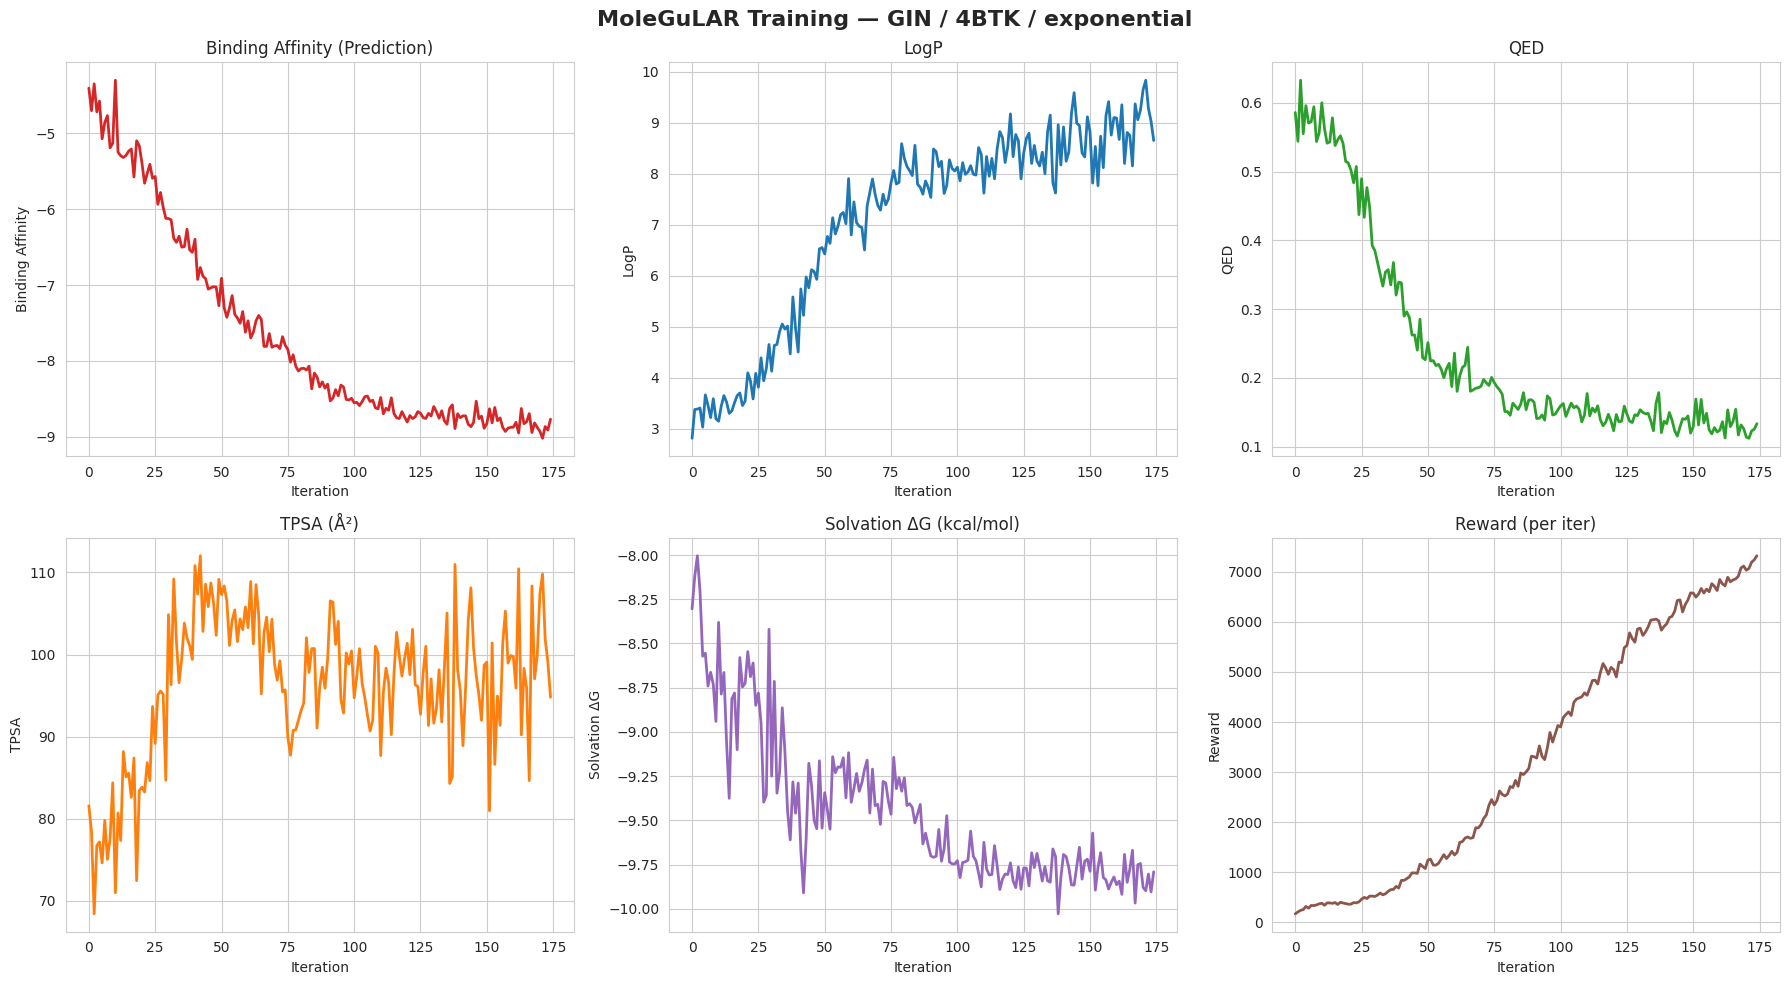

In [29]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"MoleGuLAR Training — {PREDICTOR.upper()} / {PROTEIN} / {REWARD_FUNCTION}", fontsize=16, fontweight='bold')

metrics = [
    (preds_history, "Binding Affinity (Prediction)", "tab:red"),
    (logp_history, "LogP", "tab:blue"),
    (qed_history, "QED", "tab:green"),
    (tpsa_history, "TPSA (Å²)", "tab:orange"),
    (solvation_history, "Solvation ΔG (kcal/mol)", "tab:purple"),
    (rewards_history[-len(preds_history)*N_POLICY::N_POLICY] if len(rewards_history) > 0 else [], "Reward (per iter)", "tab:brown"),
]

for ax, (data, title, color) in zip(axes.flat, metrics):
    if len(data) > 0:
        ax.plot(data, color=color, linewidth=2)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Iteration")
        ax.set_ylabel(title.split("(")[0].strip())
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

### 🧪 Generate Final Molecules

In [30]:
print("🧬 Generating molecules from the optimized model...\n")

final_molecules = []
for i in range(200):
    smi = generator.evaluate(gen_data, predict_len=120)[1:-1]
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        canonical = Chem.MolToSmiles(mol)
        final_molecules.append(canonical)

unique_mols = list(set(final_molecules))
print(f"Generated: {len(final_molecules)} | Valid: {len(final_molecules)} | Unique: {len(unique_mols)}")
print(f"Validity:  {len(final_molecules)/200*100:.1f}%")
print(f"Uniqueness: {len(unique_mols)/max(len(final_molecules),1)*100:.1f}%")

# ── Evaluate properties ──
print("\n📋 Property Distribution of Generated Molecules:")
props = []
for smi in unique_mols[:50]:
    mol = Chem.MolFromSmiles(smi)
    try:
        props.append({
            'SMILES': smi,
            'LogP': MolLogP(mol),
            'QED': qed(mol),
            'TPSA': CalcTPSA(mol),
        })
    except:
        pass

df = pandas.DataFrame(props)
display(df.describe().round(3))
print("\n🔬 Sample molecules:")
display(df.head(15))

🧬 Generating molecules from the optimized model...

Generated: 196 | Valid: 196 | Unique: 35
Validity:  98.0%
Uniqueness: 17.9%

📋 Property Distribution of Generated Molecules:


,LogP,QED,TPSA
count,35.000,35.000,35.000
mean,8.975,0.132,98.851
std,1.066,0.053,23.994
min,6.249,0.070,43.370
25%,8.150,0.115,85.350
50%,9.369,0.117,102.420
75%,9.381,0.139,111.535
max,10.760,0.364,139.720



🔬 Sample molecules:


,SMILES,LogP,QED,TPSA
0,Nc1ccc(C(=O)c2ccc(C(=O)c3ccc(C(=O)c4ccc(C(=O)c...,7.42380,0.127125,111.37
1,Cc1ccc(C(=O)c2ccc(C(=O)c3ccc(C(=O)c4ccccc4C(=O...,10.75962,0.115532,85.35
2,Cc1cccc(C(=O)c2ccc(C(=O)c3ccc(C(=O)c4ccc(C(=O)...,9.38102,0.116850,102.42
3,Cc1ccc(C(=O)c2ccc(C(=O)c3ccc(C(=O)c4ccc(C(=O)c...,9.07922,0.114908,139.72
4,O=C(O)c1cccc(C(=O)c2ccc(C(=O)c3ccc(C(=O)c4ccc(...,8.77080,0.115600,139.72
5,Cc1ccc(C(=O)c2ccc(C(=O)c3ccc(C(=O)c4ccc(C(=O)c...,9.38102,0.116850,102.42
6,Cc1ccc(C(=O)c2ccc(C(=O)c3ccc(C(=O)c4ccc(C(=O)c...,9.38102,0.116850,102.42
7,Cc1ccc(C(=O)c2ccc(C(=O)c3ccc(C(=O)c4ccc(C(=O)c...,9.38102,0.116850,102.42
8,Cc1ccc(C(=O)c2ccc(C(=O)c3cccc(C(=O)c4ccc(C(=O)...,8.15002,0.145827,85.35
9,Cc1ccc(C(=O)c2ccc(C(=O)c3cccc(C(=O)c4ccc(C(=O)...,9.38102,0.116850,102.42


####  📊 Property Distribution Plots  

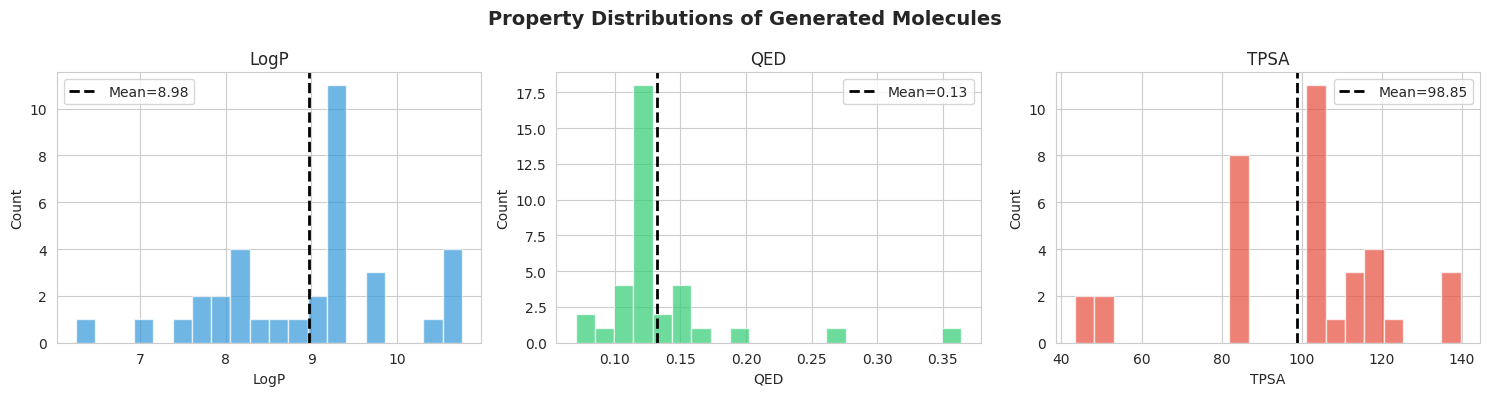

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Property Distributions of Generated Molecules", fontsize=14, fontweight='bold')

for ax, col, color in zip(axes, ['LogP', 'QED', 'TPSA'], ['#3498db', '#2ecc71', '#e74c3c']):
    if col in df.columns:
        ax.hist(df[col], bins=20, color=color, alpha=0.7, edgecolor='white')
        ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=2, label=f'Mean={df[col].mean():.2f}')
        ax.set_title(col, fontsize=12)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.legend()

plt.tight_layout()
plt.show()

## 🔧 (Optional) AutoDock-GPU
Setup> **Only needed if `PREDICTOR = "dock"`**. This section installs AutoDock-GPU and MGLTools to perform actual docking calculations.⚠️ This requires a GPU runtime and may take 10-15 minutes to build.

In [32]:
# ── OPTIONAL: Install AutoDock-GPU ──
# Uncomment and run these cells only if you need docking

# !apt-get update && apt-get install -y wget bzip2 ca-certificates curl git libxrender1
# !git clone https://github.com/ccsb-scripps/AutoDock-GPU /content/AutoDock-GPU
# %cd /content/AutoDock-GPU
# !export GPU_INCLUDE_PATH=/usr/local/cuda/include && \
#  export GPU_LIBRARY_PATH=/usr/local/cuda/lib64 && \
#  make DEVICE=CUDA NUMWI=64
# %cd {OPTIMIZER_DIR}

# ── OPTIONAL: Install MGLTools ──
# !tar -xzf {REPO_DIR}/mgltools_x86_64Linux2_1.5.6.tar_.gz -C /content/
# !cd /content/mgltools_x86_64Linux2_1.5.6 && ./install.sh

# import os
# os.environ['AUTODOCK_GPU'] = '/content/AutoDock-GPU'
# os.environ['MGL_TOOLS_PATH'] = '/content/mgltools_x86_64Linux2_1.5.6'

 ## 📤 GitHub Push

In [33]:
# ── Post-training GitHub push ─────────────────────────────────────────────────
# The training loop (Cell 53) already pushed a "final" snapshot.
# This cell re-pushes only if PUSH_TO_GITHUB is True and something
# was added after training (e.g. SSINet plots, analysis figures).

print("=" * 60)
print("📤 Post-training push (analysis outputs)")
print("=" * 60)

# Sync any new files produced by analysis cells into KAGGLE_OUTPUT_DIR
save_snapshot()
push_to_github(label="post_analysis")

print("\nDone. Check your GitHub repo → outputs/ folder.")


📤 Post-training push (analysis outputs)
[GitHub] ✅ Pushed: [AUTO] 4BTK/gin post_analysis @ 20260416_185953

Done. Check your GitHub repo → outputs/ folder.


## 🎉 Done!You've successfully run the MoleGuLAR pipeline.
 ### Key outputs:
 - **Trained model** saved to `models/model_<reward>_<remarks>`- **Generated molecules** with optimized binding affinity and drug-like properties
 - **Training curves** showing optimization progress
 ### Next Steps
 - Increase `NUM_ITERATIONS` to 175 for full training
 - Enable multi-objective: set `USE_LOGP=True`, `USE_QED=True`, `SWITCH_MODE=True`
 - Try different proteins or reward functions- Use the Analysis notebook (`Analysis/Analysis.ipynb`) for deeper analysis